# Dialysis Folder Label Project — Clean Colab Version

這份整理版 Notebook 以 **folder-based label** 為主實驗，並整合：

1. Excel 讀取與欄位統一  
2. session 切分  
3. IQR 去離群值 + 線性插值 + 中值濾波  
4. session-level 特徵萃取  
5. group-aware split  
6. group-level aggregation  
7. 五模型比較  
8. 5-fold CV  
9. Top-K feature selection + XGBoost  
10. threshold tuning  
11. MIL-like probability aggregation  
12. optional high-confidence mixed label 補充實驗

建議依序由上到下執行。主實驗請維持 `LABEL_MODE = "folder"`。


In [1]:
# 0. 安裝與匯入
!pip install -q xlrd

import os
import warnings
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings("ignore")
print("✅ 環境完成")

# 1. 全域設定
BASE_PATH = '/content/drive/My Drive/'
FOLDER_ABNORMAL = '掉血壓名單'      # 原始資料夾標籤 = 1
FOLDER_NORMAL = '不掉血壓名單'      # 原始資料夾標籤 = 0

abnormal_path = os.path.join(BASE_PATH, FOLDER_ABNORMAL)
normal_path = os.path.join(BASE_PATH, FOLDER_NORMAL)

# 主要模式：
# "folder" = 直接使用資料夾標籤（老師建議版本；較適合作業主實驗）
# "rule"   = 使用 session 規則式標籤（可能有 label leakage，僅作對照）
LABEL_MODE = "folder"

# session 切分與清洗
SESSION_GAP_HOURS = 6
MIN_LEN = 30
CORE_MISSING_RATIO = 0.6
MAX_LEN = 300
DROP_COL_THRESHOLD = 0.95

# 規則式標籤門檻（只有 LABEL_MODE='rule' 會用到）
RULE_BP_COL = 'MAX_BLOOD'
LOW_THRESHOLD = 90
DROP_THRESHOLD = 30
DBP_LOW_THRESHOLD = 50

# feature columns
PREFERRED_FEATURES = [
    'TOTAL_UF', 'BLOOD_FLOW', 'CONDUCTIVITY',
    'VENOUS', 'TEMP', 'MAX_BLOOD', 'MIN_BLOOD',
    'PULSE', 'TMP', 'UF', 'DIA_FLOW', 'TARGET_UF',
    'SYRINGE_FLOW_RATE', 'TIMES', 'MANUAL_INPUT',
    'HD_SOURCE', 'ALERT', 'BLOOD_FUN', 'BREATH'
]


# 平衡 training set 的最低少數類樣本數
MIN_MINORITY_FOR_BALANCE = 30
print(f"✅ LABEL_MODE = {LABEL_MODE}")

Mounted at /content/drive
✅ 環境完成
✅ LABEL_MODE = folder


## 1. 讀取資料與欄位偵測

In [2]:
# 2. 讀檔與欄位判斷
def detect_time_column(df):
    for c in ['REC_DATE', 'DATA_TIME', 'UDATE']:
        if c in df.columns:
            return c
    return None

def read_single_xls(file_path, label, source_folder):
    try:
        df = pd.read_excel(file_path, engine='xlrd')
        return {
            'file_name': os.path.basename(file_path),
            'file_path': file_path,
            'label': label,
            'source_folder': source_folder,
            'data': df
        }
    except Exception as e:
        print(f"❌ 讀取失敗: {file_path}, error={e}")
        return None

def read_all_xls_in_folder(folder_path, label, source_folder):
    items = []
    if not os.path.exists(folder_path):
        print(f"❌ 找不到資料夾: {folder_path}")
        return items

    files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.xls')])
    print(f"\n📂 讀取資料夾: {os.path.basename(folder_path)}")
    print(f"   共找到 {len(files)} 個 xls 檔")

    for file in files:
        file_path = os.path.join(folder_path, file)
        result = read_single_xls(file_path, label, source_folder)
        if result is not None:
            print(f"   ✅ {file} -> shape={result['data'].shape}")
            items.append(result)
    return items

abnormal_files = read_all_xls_in_folder(abnormal_path, label=1, source_folder=FOLDER_ABNORMAL)
normal_files = read_all_xls_in_folder(normal_path, label=0, source_folder=FOLDER_NORMAL)
all_file_items = abnormal_files + normal_files

print("\n==============================")
print("✅ 全部檔案讀取完成")
print("總檔案數:", len(all_file_items))
print("掉血壓檔案數:", len(abnormal_files))
print("不掉血壓檔案數:", len(normal_files))
print("==============================")


📂 讀取資料夾: 掉血壓名單
   共找到 10 個 xls 檔
   ✅ 01.xls -> shape=(55907, 44)
   ✅ 02.xls -> shape=(56645, 44)
   ✅ 03.xls -> shape=(61514, 44)
   ✅ 04.xls -> shape=(50267, 44)
   ✅ 05.xls -> shape=(61503, 44)
   ✅ 06.xls -> shape=(61364, 44)
   ✅ 07.xls -> shape=(43617, 44)
   ✅ 08.xls -> shape=(60699, 44)
   ✅ 09.xls -> shape=(61703, 44)
   ✅ 10.xls -> shape=(24124, 44)

📂 讀取資料夾: 不掉血壓名單
   共找到 10 個 xls 檔
   ✅ 01.xls -> shape=(47194, 44)
   ✅ 02.xls -> shape=(38649, 44)
   ✅ 03.xls -> shape=(61140, 44)
   ✅ 04.xls -> shape=(31280, 44)
   ✅ 05.xls -> shape=(28673, 44)
   ✅ 06.xls -> shape=(55769, 44)
   ✅ 07.xls -> shape=(30693, 44)
   ✅ 08.xls -> shape=(49892, 44)
   ✅ 09.xls -> shape=(56406, 44)
   ✅ 10.xls -> shape=(52975, 44)

✅ 全部檔案讀取完成
總檔案數: 20
掉血壓檔案數: 10
不掉血壓檔案數: 10


In [3]:
# 3. 第一次掃描：建立 usable_file_items 與統一欄位
all_feature_columns = set()
usable_file_items = []

for item in all_file_items:
    df_raw = item['data'].copy()
    time_col = detect_time_column(df_raw)

    if time_col is None or 'PAT_NO' not in df_raw.columns:
        print(f"⚠️ 略過 {item['file_name']}：缺少 PAT_NO 或時間欄位")
        continue

    df = df_raw.copy()
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.dropna(subset=['PAT_NO', time_col]).copy()

    if df.empty:
        print(f"⚠️ 略過 {item['file_name']}：有效資料為空")
        continue

    df['PAT_NO'] = df['PAT_NO'].astype(str)

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')

    if numeric_df.shape[1] == 0:
        print(f"⚠️ 略過 {item['file_name']}：無數值欄位")
        continue

    missing_ratio = numeric_df.isna().mean()
    kept_cols = missing_ratio[missing_ratio <= DROP_COL_THRESHOLD].index.tolist()
    numeric_df = numeric_df[kept_cols].copy()

    if len(numeric_df.columns) == 0:
        print(f"⚠️ 略過 {item['file_name']}：刪除高缺失欄位後無特徵")
        continue

    file_feature_cols = [c for c in PREFERRED_FEATURES if c in numeric_df.columns]
    if len(file_feature_cols) < 5:
        file_feature_cols = numeric_df.columns.tolist()

    all_feature_columns.update(file_feature_cols)

    usable_file_items.append({
        'file_name': item['file_name'],
        'file_path': item['file_path'],
        'label': item['label'],
        'source_folder': item['source_folder'],
        'time_col': time_col,
        'data': df
    })

all_feature_columns = sorted(list(all_feature_columns))

print("\n📌 統一後特徵數:", len(all_feature_columns))
print("📌 特徵欄位:", all_feature_columns)
print("📌 可用檔案數:", len(usable_file_items))


📌 統一後特徵數: 19
📌 特徵欄位: ['ALERT', 'BLOOD_FLOW', 'BLOOD_FUN', 'BREATH', 'CONDUCTIVITY', 'DIA_FLOW', 'HD_SOURCE', 'MANUAL_INPUT', 'MAX_BLOOD', 'MIN_BLOOD', 'PULSE', 'SYRINGE_FLOW_RATE', 'TARGET_UF', 'TEMP', 'TIMES', 'TMP', 'TOTAL_UF', 'UF', 'VENOUS']
📌 可用檔案數: 20


In [4]:
# 4. 第二次掃描：建立全域 median
value_pool = {col: [] for col in all_feature_columns}

for item in usable_file_items:
    df = item['data'].copy()
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')
    numeric_df = numeric_df.reindex(columns=all_feature_columns)

    for col in all_feature_columns:
        vals = pd.to_numeric(numeric_df[col], errors='coerce').dropna().values
        if len(vals) > 0:
            value_pool[col].extend(vals.tolist())

global_medians = {}
for col in all_feature_columns:
    global_medians[col] = float(np.median(value_pool[col])) if len(value_pool[col]) > 0 else 0.0

print("✅ 已建立 global_medians")

✅ 已建立 global_medians


## 2. Session 切分、規則標籤、統計特徵函式

In [5]:
# 5. session 切分 / 清洗 / 標籤 / 特徵
def assign_sessions(df_in, patient_col='PAT_NO',
                    time_col='REC_DATE',
                    gap_hours=6):
    df_in = df_in.copy()
    df_in = df_in.sort_values([patient_col, time_col]).reset_index(drop=True)

    session_ids = []
    current_session = 0
    prev_patient = None
    prev_time = None

    for _, row in df_in.iterrows():
        patient = row[patient_col]
        t = row[time_col]

        new_session = False
        if prev_patient is None:
            new_session = True
        elif patient != prev_patient:
            new_session = True
        else:
            delta_hours = (t - prev_time).total_seconds() / 3600.0
            if delta_hours > gap_hours:
                new_session = True

        if new_session:
            current_session += 1

        session_ids.append(f"S{current_session:05d}")
        prev_patient = patient
        prev_time = t

    df_in['SESSION_ID'] = session_ids
    return df_in

def clean_session_df(session_df, feature_cols, global_medians, min_len=30, core_missing_ratio=0.6):
    x = session_df[feature_cols].copy()

    row_valid_ratio = x.notna().mean(axis=1)
    x = x[row_valid_ratio >= core_missing_ratio].copy()

    if len(x) < min_len:
        return None

    x = x.interpolate(method='linear', limit_direction='both', axis=0)
    x = x.ffill().bfill()

    for col in feature_cols:
        if x[col].isna().all():
            x[col] = global_medians[col]
        else:
            x[col] = x[col].fillna(x[col].median())

    x = x.fillna(pd.Series(global_medians))
    return x

def rule_based_label(df_feat,
                     sbp_col='MAX_BLOOD',
                     dbp_col='MIN_BLOOD',
                     low_threshold=LOW_THRESHOLD,
                     drop_threshold=DROP_THRESHOLD,
                     dbp_low_threshold=DBP_LOW_THRESHOLD):
    """
    1 = abnormal
    0 = normal

    規則：
    A. 收縮壓最低值 < low_threshold
    B. 收縮壓相對起始 baseline 下降 >= drop_threshold
    C. 舒張壓最低值 < dbp_low_threshold

    判異常條件：
    (A and B) 或 (A and C)
    """

    if sbp_col not in df_feat.columns:
      return 0

    sbp = pd.to_numeric(df_feat[sbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    if len(sbp) < 5:
      return 0

    sbp = sbp.values.astype(float)

    # 用前5筆平均當 baseline，比第一筆穩
    baseline = np.mean(sbp[:5])
    sbp_min = np.min(sbp)
    sbp_drop = baseline - sbp_min

    rule_a = sbp_min < low_threshold
    rule_b = sbp_drop >= drop_threshold

    rule_c = False
    if dbp_col in df_feat.columns:
        dbp = pd.to_numeric(df_feat[dbp_col], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
        if len(dbp) >= 5:
            dbp = dbp.values.astype(float)
            dbp_min = np.min(dbp)
            rule_c = dbp_min < dbp_low_threshold

    if (rule_a and rule_b) or (rule_a and rule_c):
        return 1
    return 0

def extract_stat_features(df_feat):
    diff = df_feat.diff().fillna(0)
    n = len(df_feat)
    s1 = df_feat.iloc[:max(1, n // 3)]
    s2 = df_feat.iloc[max(1, n // 3):max(2, 2 * n // 3)]
    s3 = df_feat.iloc[max(2, 2 * n // 3):]

    slopes = []
    x_idx = np.arange(len(df_feat))
    for col in df_feat.columns:
        vals = pd.to_numeric(df_feat[col], errors='coerce').ffill().bfill().fillna(0).values
        if len(vals) >= 2 and np.std(vals) > 1e-8:
            m = np.polyfit(x_idx, vals, 1)[0]
        else:
            m = 0.0
        slopes.append(m)

    bp_special = []
    bp_col = 'MIN_BLOOD' if 'MIN_BLOOD' in df_feat.columns else None
    if bp_col is not None:
        vals = pd.to_numeric(df_feat[bp_col], errors='coerce').ffill().bfill().fillna(0).values
        if len(vals) > 0:
            bp_special.extend([
                np.min(vals),
                np.max(vals),
                vals[-1] - vals[0],
                vals[0] - np.min(vals),
                np.argmin(vals) / max(len(vals)-1, 1)
            ])
        else:
            bp_special.extend([0, 0, 0, 0, 0])
    else:
        bp_special.extend([0, 0, 0, 0, 0])

    feats = np.concatenate([
        df_feat.mean().values,
        df_feat.std(ddof=0).values,
        df_feat.min().values,
        df_feat.max().values,
        df_feat.median().values,
        df_feat.quantile(0.25).values,
        df_feat.quantile(0.75).values,
        (df_feat.max() - df_feat.min()).values,
        df_feat.iloc[0].values,
        df_feat.iloc[-1].values,
        (df_feat.iloc[-1] - df_feat.iloc[0]).values,
        diff.abs().mean().values,
        diff.abs().std(ddof=0).values,
        s1.mean().values,
        s2.mean().values,
        s3.mean().values,
        np.array(slopes, dtype=np.float32),
        np.array(bp_special, dtype=np.float32)
    ]).astype(np.float32)

    return feats

## 3. IQR 去離群值 + 中值濾波去雜訊函式

這段會覆蓋前面原始的 `clean_session_df()`，後續建立 session 時會使用去雜訊版本。

In [6]:
# =========================================================
# Denoising 套件
# =========================================================

import numpy as np
import pandas as pd

try:
    from scipy.signal import medfilt
except ImportError:
    !pip install scipy -q
    from scipy.signal import medfilt

print("✅ scipy.signal.medfilt ready")

✅ scipy.signal.medfilt ready


In [7]:
# =========================================================
# IQR outlier removal + linear interpolation + median filter
# =========================================================

def remove_outliers_iqr_nan_1d(data, k = 1.5):
    """
    使用 IQR 方法偵測 1D array 的離群值，並將離群值設為 NaN。

    Parameters
    ----------
    data : array-like
        一維數值資料。
    k : float
        IQR 倍數。常用 1.5，若太嚴格可改 3.0。

    Returns
    -------
    cleaned : np.ndarray
        離群值設為 NaN 後的資料。
    mask_outlier : np.ndarray
        True 表示該位置是離群值。
    bounds : tuple
        lower, upper 邊界。
    """
    arr = np.asarray(data, dtype=float).copy()

    valid = arr[~np.isnan(arr)]
    if len(valid) < 4:
        return arr, np.zeros_like(arr, dtype=bool), (np.nan, np.nan)

    q1 = np.nanpercentile(valid, 25)
    q3 = np.nanpercentile(valid, 75)
    iqr = q3 - q1

    if np.isnan(iqr) or iqr == 0:
        return arr, np.zeros_like(arr, dtype=bool), (q1, q3)

    lower = q1 - k * iqr
    upper = q3 + k * iqr

    mask_outlier = (arr < lower) | (arr > upper)
    arr[mask_outlier] = np.nan

    return arr, mask_outlier, (lower, upper)


def linear_interpolate_nan_1d(data):
    """
    對 1D array 中的 NaN 做線性插值。
    若全部都是 NaN，則回傳原資料。
    """
    arr = np.asarray(data, dtype=float).copy()
    x = np.arange(len(arr))

    valid_mask = ~np.isnan(arr)

    if valid_mask.sum() == 0:
        return arr

    if valid_mask.sum() == 1:
        arr[:] = arr[valid_mask][0]
        return arr

    arr[~valid_mask] = np.interp(
        x[~valid_mask],
        x[valid_mask],
        arr[valid_mask]
    )

    return arr


def apply_median_filter_1d(data, kernel_size = 5):
    """
    對 1D array 做中值濾波。
    kernel_size 必須是奇數，且不可大於資料長度。
    """
    arr = np.asarray(data, dtype=float).copy()

    n = len(arr)
    if n < 3:
        return arr

    # kernel_size 必須是奇數
    if kernel_size % 2 == 0:
        kernel_size += 1

    # kernel_size 不可大於資料長度
    if kernel_size > n:
        kernel_size = n if n % 2 == 1 else n - 1

    if kernel_size < 3:
        return arr

    return medfilt(arr, kernel_size=kernel_size)


def denoise_series_iqr_median(data, k = 1.5, kernel_size = 5):
    """
    單一欄位完整去雜訊流程：
    1. IQR 找離群值，設為 NaN
    2. 線性插值補 NaN
    3. 中值濾波去 spike
    """
    arr = np.asarray(data, dtype=float).copy()

    arr_iqr, mask_outlier, bounds = remove_outliers_iqr_nan_1d(arr, k=k)
    arr_interp = linear_interpolate_nan_1d(arr_iqr)
    arr_med = apply_median_filter_1d(arr_interp, kernel_size=kernel_size)

    return arr_med, mask_outlier, bounds

In [8]:
# =========================================================
# clean_session_df with IQR + Median Filter
# =========================================================

def clean_session_df(session_df,
                     feature_cols,
                     global_medians,
                     min_len = 30,
                     core_missing_ratio = 0.6,
                     use_denoise = True,
                     iqr_k = 1.5,
                     median_kernel_size = 5,
                     denoise_cols = None):
    """
    清洗單一 session。

    流程：
    1. 保留 feature columns
    2. 移除缺失比例過高的 row
    3. 轉數值
    4. 初步插值與補值
    5. IQR 去離群值 + 線性插值 + 中值濾波
    6. 最終補值

    Parameters
    ----------
    use_denoise : bool
        是否啟用 IQR + median filter。
    iqr_k : float
        IQR 倍數。1.5 較嚴格，3.0 較保守。
    median_kernel_size : int
        中值濾波視窗大小，必須為奇數。建議 3 或 5。
    denoise_cols : list or None
        指定哪些欄位做 denoise。None 表示對所有 feature_cols 做。
    """

    x = session_df[feature_cols].copy()

    # -----------------------------------------------------
    # 1. 轉成數值
    # -----------------------------------------------------
    for col in feature_cols:
        x[col] = pd.to_numeric(x[col], errors="coerce")

    # -----------------------------------------------------
    # 2. 移除缺失比例太高的 rows
    # -----------------------------------------------------
    row_valid_ratio = x.notna().mean(axis=1)
    x = x[row_valid_ratio >= core_missing_ratio].copy()

    if len(x) < min_len:
        return None

    # -----------------------------------------------------
    # 3. 初步插值補值
    # -----------------------------------------------------
    x = x.interpolate(method="linear", limit_direction="both", axis=0)
    x = x.ffill().bfill()

    for col in feature_cols:
        if x[col].isna().all():
            x[col] = global_medians[col]
        else:
            x[col] = x[col].fillna(x[col].median())

    x = x.fillna(pd.Series(global_medians))

    # -----------------------------------------------------
    # 4. IQR + Median denoising
    # -----------------------------------------------------
    if use_denoise:
        if denoise_cols is None:
            denoise_cols = feature_cols

        for col in denoise_cols:
            if col not in x.columns:
                continue

            values = pd.to_numeric(x[col], errors="coerce").values.astype(float)

            # 如果變化太小，不處理
            if np.nanstd(values) < 1e-8:
                continue

            denoised_values, mask_outlier, bounds = denoise_series_iqr_median(
                values,
                k=iqr_k,
                kernel_size=median_kernel_size
            )

            # 如果 denoise 後仍有 NaN，用原本 median / global median 補
            if np.isnan(denoised_values).any():
                temp = pd.Series(denoised_values)
                temp = temp.interpolate(method="linear", limit_direction="both")
                temp = temp.ffill().bfill()
                temp = temp.fillna(global_medians[col])
                denoised_values = temp.values

            x[col] = denoised_values

    # -----------------------------------------------------
    # 5. 最終保險補值
    # -----------------------------------------------------
    x = x.replace([np.inf, -np.inf], np.nan)
    x = x.interpolate(method="linear", limit_direction="both", axis=0)
    x = x.ffill().bfill()

    for col in feature_cols:
        if x[col].isna().all():
            x[col] = global_medians[col]
        else:
            x[col] = x[col].fillna(x[col].median())

    x = x.fillna(pd.Series(global_medians))

    return x

In [9]:
# =========================================================
# 建議 denoise 欄位
# =========================================================

DENOISE_COLS = [
    "TOTAL_UF",
    "BLOOD_FLOW",
    "CONDUCTIVITY",
    "VENOUS",
    "TEMP",
    "MAX_BLOOD",
    "MIN_BLOOD",
    "PULSE",
    "TMP",
    "UF",
    "DIA_FLOW",
    "TARGET_UF",
    "SYRINGE_FLOW_RATE",
    "TIMES",
    "BLOOD_FUN",
    "BREATH"
]

DENOISE_COLS = [c for c in DENOISE_COLS if c in all_feature_columns]

print("Denoise columns:")
print(DENOISE_COLS)

Denoise columns:
['TOTAL_UF', 'BLOOD_FLOW', 'CONDUCTIVITY', 'VENOUS', 'TEMP', 'MAX_BLOOD', 'MIN_BLOOD', 'PULSE', 'TMP', 'UF', 'DIA_FLOW', 'TARGET_UF', 'SYRINGE_FLOW_RATE', 'TIMES', 'BLOOD_FUN', 'BREATH']


## 4. 建立 Session 樣本（Folder Label + Denoising）

這一格是主資料集建立步驟。若要測試較強去雜訊，可把 `iqr_k=3.0, median_kernel_size=3` 改成 `iqr_k=1.5, median_kernel_size=5`。

In [24]:
# =========================================================
# 6. 建立 session 樣本
# =========================================================

LABEL_MODE = "folder"

sequences = []
labels = []
stats_features = []
session_meta = []

total_candidate_sessions = 0
kept_sessions = 0
skipped_sessions = 0

# 用來保存一組簡報展示用 raw vs cleaned session
example_raw_session = None
example_cleaned_session = None
example_session_info = None

VISUAL_TARGET_COLS = [
    "MAX_BLOOD",
    "MIN_BLOOD",
    "PULSE",
    "VENOUS",
    "TMP",
    "UF",
    "BLOOD_FLOW"
]

for item in usable_file_items:
    file_name = item['file_name']
    source_folder = item['source_folder']
    original_file_label = item['label']
    time_col = item['time_col']
    df = item['data'].copy()

    df = df.sort_values(['PAT_NO', time_col]).reset_index(drop=True)

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.drop(columns=['PAT_NO'], errors='ignore')
    numeric_df = numeric_df.reindex(columns=all_feature_columns)

    df_model = pd.concat(
        [
            df[['PAT_NO', time_col]].reset_index(drop=True),
            numeric_df.reset_index(drop=True)
        ],
        axis=1
    )

    df_model = assign_sessions(
        df_model,
        patient_col='PAT_NO',
        time_col=time_col,
        gap_hours=SESSION_GAP_HOURS
    )

    grouped = df_model.groupby('SESSION_ID')
    total_candidate_sessions += df_model['SESSION_ID'].nunique()

    for session_id, g in grouped:
        g = g.sort_values(time_col).reset_index(drop=True)

        # =====================================================
        # 主流程去雜訊：這是模型實際使用的 cleaned_x
        # =====================================================
        cleaned_x = clean_session_df(
            g,
            feature_cols=all_feature_columns,
            global_medians=global_medians,
            min_len=MIN_LEN,
            core_missing_ratio=CORE_MISSING_RATIO,
            use_denoise=True,
            iqr_k=1.5,
            median_kernel_size=5,
            denoise_cols=DENOISE_COLS
        )

        if cleaned_x is None:
            skipped_sessions += 1
            continue

        # =====================================================
        # 保存一組展示用 raw vs cleaned session
        # 注意：這裡沒有重新去雜訊，只保存 g 和 cleaned_x
        # =====================================================
        if example_raw_session is None:
            best_col = None
            best_score = -1

            for target_col in VISUAL_TARGET_COLS:
                if target_col not in g.columns:
                    continue

                if target_col not in cleaned_x.columns:
                    continue

                raw_values = pd.to_numeric(g[target_col], errors="coerce")
                cleaned_values = pd.to_numeric(cleaned_x[target_col], errors="coerce")

                raw_valid = raw_values.dropna()
                cleaned_valid = cleaned_values.dropna()

                # 基本條件：長度夠、不是全空、不是全 0
                if len(g) < 80:
                    continue

                if len(raw_valid) < 80:
                    continue

                if len(cleaned_valid) < 80:
                    continue

                if (raw_valid != 0).mean() < 0.8:
                    continue

                if raw_valid.std() < 1:
                    continue

                # 用 raw 與 cleaned 的差異當分數
                n_compare = min(len(raw_values), len(cleaned_values), 200)
                raw_part = pd.to_numeric(raw_values.iloc[:n_compare], errors="coerce").values.astype(float)
                clean_part = pd.to_numeric(cleaned_values.iloc[:n_compare], errors="coerce").values.astype(float)

                if len(raw_part) == 0 or len(clean_part) == 0:
                    continue

                diff_score = np.nanmean(np.abs(raw_part - clean_part))

                # 如果差異比較大，代表比較適合展示去雜訊效果
                if diff_score > best_score:
                    best_score = diff_score
                    best_col = target_col

            if best_col is not None:
                example_raw_session = g.copy()
                example_cleaned_session = cleaned_x.copy()
                example_session_info = {
                    "source_folder": source_folder,
                    "file_name": file_name,
                    "session_id": session_id,
                    "patient_no": g["PAT_NO"].iloc[0],
                    "length_raw": len(g),
                    "length_cleaned": len(cleaned_x),
                    "target_col": best_col,
                    "difference_score": best_score
                }

                print("====================================================")
                print("已保存展示用 raw vs cleaned session")
                print("====================================================")
                print(example_session_info)

        seq = cleaned_x.values.astype(np.float32)

        if LABEL_MODE == "folder":
            session_label = original_file_label

        elif LABEL_MODE == "rule":
            session_label = rule_based_label(
                cleaned_x,
                sbp_col='MAX_BLOOD',
                dbp_col='MIN_BLOOD',
                low_threshold=LOW_THRESHOLD,
                drop_threshold=DROP_THRESHOLD,
                dbp_low_threshold=DBP_LOW_THRESHOLD
            )

        else:
            raise ValueError("LABEL_MODE 必須是 'folder' 或 'rule'")

        sequences.append(seq)
        labels.append(session_label)
        stats_features.append(extract_stat_features(cleaned_x))

        session_meta.append({
            'source_folder': source_folder,
            'file_name': file_name,
            'original_file_label': original_file_label,
            'label': session_label,
            'session_id': f"{file_name}_{session_id}",
            'patient_no': g['PAT_NO'].iloc[0],
            'start_time': g[time_col].iloc[0],
            'end_time': g[time_col].iloc[-1],
            'length': len(seq),
            'group_id': f"{source_folder}_{file_name}_{g['PAT_NO'].iloc[0]}"
        })

        kept_sessions += 1

print("\n==============================")
print(f"✅ Session 建立完成（LABEL_MODE = {LABEL_MODE}）")
print("候選 session 數:", total_candidate_sessions)
print("保留 session 數:", kept_sessions)
print("略過 session 數:", skipped_sessions)
print("==============================")

session_meta_df = pd.DataFrame(session_meta)
display(session_meta_df.head())

print("\n==============================")
print("展示用 session 檢查")
print("==============================")

if example_session_info is not None:
    print("已成功保存展示用 session:")
    print(example_session_info)
else:
    print("沒有找到適合展示的 session，可以降低篩選條件。")

已保存展示用 raw vs cleaned session
{'source_folder': '掉血壓名單', 'file_name': '01.xls', 'session_id': 'S01245', 'patient_no': '2', 'length_raw': 105, 'length_cleaned': 105, 'target_col': 'BLOOD_FLOW', 'difference_score': np.float64(37.68571428571428)}

✅ Session 建立完成（LABEL_MODE = folder）
候選 session 數: 42268
保留 session 數: 6279
略過 session 數: 35989


,source_folder,file_name,original_file_label,label,session_id,patient_no,start_time,end_time,length,group_id
0,掉血壓名單,01.xls,1,1,01.xls_S00056,1,2016-03-21 07:27:48,2016-03-21 11:59:26,37,掉血壓名單_01.xls_1
1,掉血壓名單,01.xls,1,1,01.xls_S00066,1,2016-04-13 07:43:49,2016-04-13 12:19:24,44,掉血壓名單_01.xls_1
2,掉血壓名單,01.xls,1,1,01.xls_S00072,1,2016-04-27 07:33:45,2016-04-27 11:58:57,47,掉血壓名單_01.xls_1
3,掉血壓名單,01.xls,1,1,01.xls_S00075,1,2016-05-04 07:29:26,2016-05-04 11:54:12,32,掉血壓名單_01.xls_1
4,掉血壓名單,01.xls,1,1,01.xls_S00077,1,2016-05-09 07:39:42,2016-05-09 12:05:41,30,掉血壓名單_01.xls_1



展示用 session 檢查
已成功保存展示用 session:
{'source_folder': '掉血壓名單', 'file_name': '01.xls', 'session_id': 'S01245', 'patient_no': '2', 'length_raw': 105, 'length_cleaned': 105, 'target_col': 'BLOOD_FLOW', 'difference_score': np.float64(37.68571428571428)}


Figure saved to: raw_vs_training_denoised_signal.png


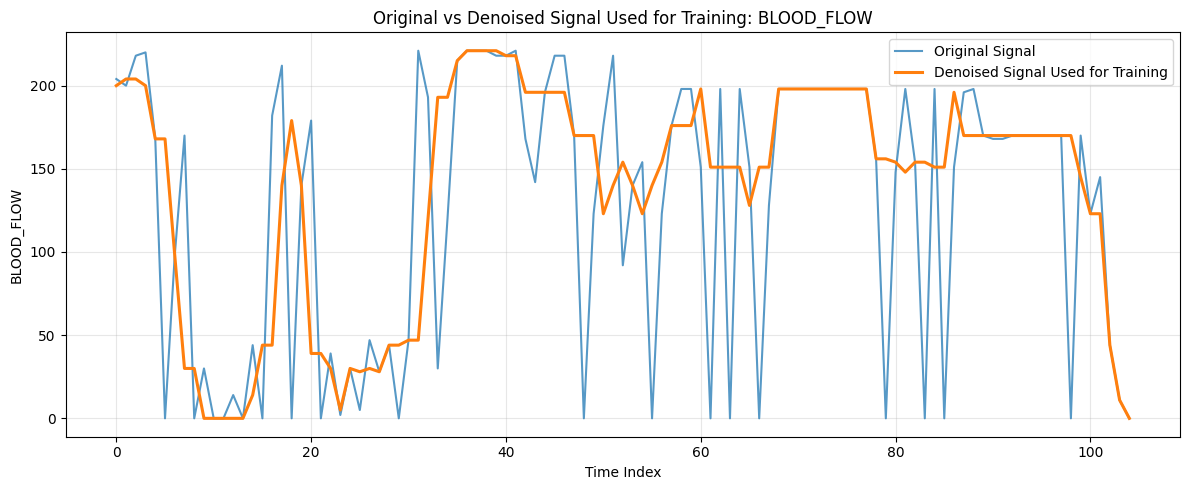

Signal Summary
Column: BLOOD_FLOW
Original length: 105
Cleaned length: 105
Original mean: 127.18095238095238
Original std: 82.46220270695808
Original min: 0.0
Original max: 221.0
Cleaned mean: 137.38095238095238
Cleaned std: 67.91779077572293
Cleaned min: 0.0
Cleaned max: 221.0
Mean absolute difference: 37.68571428571428


In [27]:
# =========================================================
# Plot Original vs Training Denoised Signal
# 比較主流程中的 g 和 cleaned_x
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_raw_vs_cleaned_session(
    raw_session,
    cleaned_session,
    col="MAX_BLOOD",
    start=0,
    end=200,
    save_path=None
):
    if raw_session is None or cleaned_session is None:
        print("沒有保存到 example_raw_session 或 example_cleaned_session")
        return

    if col not in raw_session.columns:
        print(f"raw_session 沒有欄位 {col}")
        return

    if col not in cleaned_session.columns:
        print(f"cleaned_session 沒有欄位 {col}")
        return

    raw = pd.to_numeric(raw_session[col], errors="coerce").values.astype(float)
    cleaned = pd.to_numeric(cleaned_session[col], errors="coerce").values.astype(float)

    n = min(len(raw), len(cleaned), end)

    raw = raw[start:n]
    cleaned = cleaned[start:n]

    if len(raw) == 0 or len(cleaned) == 0:
        print("選到的區間沒有資料，請調整 start/end")
        return

    valid_raw = raw[~np.isnan(raw)]
    valid_cleaned = cleaned[~np.isnan(cleaned)]

    if len(valid_raw) == 0 or len(valid_cleaned) == 0:
        print("這段資料全是 NaN，請換一個 session")
        return

    plt.figure(figsize=(12, 5))

    plt.plot(
        raw,
        label="Original Signal",
        linewidth=1.5,
        alpha=0.75
    )

    plt.plot(
        cleaned,
        label="Denoised Signal Used for Training",
        linewidth=2.2
    )

    plt.title(f"Original vs Denoised Signal Used for Training: {col}")
    plt.xlabel("Time Index")
    plt.ylabel(col)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Figure saved to:", save_path)

    plt.show()

    print("====================================================")
    print("Signal Summary")
    print("====================================================")
    print("Column:", col)
    print("Original length:", len(raw))
    print("Cleaned length:", len(cleaned))
    print("Original mean:", np.nanmean(raw))
    print("Original std:", np.nanstd(raw))
    print("Original min:", np.nanmin(raw))
    print("Original max:", np.nanmax(raw))
    print("Cleaned mean:", np.nanmean(cleaned))
    print("Cleaned std:", np.nanstd(cleaned))
    print("Cleaned min:", np.nanmin(cleaned))
    print("Cleaned max:", np.nanmax(cleaned))
    print("Mean absolute difference:", np.nanmean(np.abs(raw - cleaned)))

if example_session_info is not None:
    plot_raw_vs_cleaned_session(
        raw_session=example_raw_session,
        cleaned_session=example_cleaned_session,
        col=example_session_info["target_col"],
        start=0,
        end=200,
        save_path="raw_vs_training_denoised_signal.png"
    )
else:
    print("沒有可用的 example_session_info，請先重新執行建立 session 樣本那一段。")

## 5. 建立 X / y / groups，並進行 group-aware split

In [28]:
# 7. 建立 X_seq / X_mask / stats_X / y，並檢查標籤分布
n_samples = len(sequences)
n_features = len(all_feature_columns)

X_seq = np.zeros((n_samples, MAX_LEN, n_features), dtype=np.float32)
X_mask = np.zeros((n_samples, MAX_LEN), dtype=np.float32)

for i, seq in enumerate(sequences):
    seq = np.nan_to_num(seq, nan=0.0, posinf=0.0, neginf=0.0)
    seq_scaled = seq.copy()
    col_std = np.std(seq_scaled, axis=0)
    non_const_idx = col_std > 1e-8

    if np.any(non_const_idx):
        scaler = StandardScaler()
        seq_scaled[:, non_const_idx] = scaler.fit_transform(seq_scaled[:, non_const_idx])

    length = min(len(seq_scaled), MAX_LEN)
    X_seq[i, :length, :] = seq_scaled[:length]
    X_mask[i, :length] = 1.0

y = np.array(labels, dtype=np.int64)
stats_X = np.array(stats_features, dtype=np.float32)
stats_X = SimpleImputer(strategy='median').fit_transform(stats_X)

print("\n==============================")
print("✅ 最終資料完成")
print("X_seq shape      :", X_seq.shape)
print("X_mask shape     :", X_mask.shape)
print("stats_X shape    :", stats_X.shape)
print("y_shape          :", y.shape)
print("session_meta_df  :", session_meta_df.shape)
print("異常 session 數  :", int(np.sum(y == 1)))
print("正常 session 數  :", int(np.sum(y == 0)))
print("平均 session 長度 :", round(session_meta_df['length'].mean(), 2) if len(session_meta_df) > 0 else 0)
print("==============================")

label_counts = pd.Series(y).value_counts().sort_index()
print("\n標籤分布：")
print(label_counts)

minority_count = label_counts.min() if len(label_counts) >= 2 else 0
imbalance_ratio = label_counts.max() / max(minority_count, 1) if len(label_counts) >= 2 else np.inf
print(f"\n少數類樣本數: {minority_count}")
print(f"類別不平衡比（多數/少數）: {imbalance_ratio:.2f}")

if len(label_counts) < 2 or minority_count < 20 or imbalance_ratio > 20:
    print("⚠️ 警告：目前標籤分布非常不平衡，Accuracy 可能失真。")
    print("⚠️ 建議調整 LABEL_MODE 或規則門檻（LOW_THRESHOLD / DROP_THRESHOLD）。")


✅ 最終資料完成
X_seq shape      : (6279, 300, 19)
X_mask shape     : (6279, 300)
stats_X shape    : (6279, 328)
y_shape          : (6279,)
session_meta_df  : (6279, 10)
異常 session 數  : 3748
正常 session 數  : 2531
平均 session 長度 : 54.76

標籤分布：
0    2531
1    3748
Name: count, dtype: int64

少數類樣本數: 2531
類別不平衡比（多數/少數）: 1.48


In [29]:
# 8. group-aware split
session_meta_df["group_id"] = (
    session_meta_df["source_folder"].astype(str) + "_" +
    session_meta_df["file_name"].astype(str) + "_" +
    session_meta_df["patient_no"].astype(str)
)

groups = session_meta_df["group_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(stats_X, y, groups=groups))

X_train = stats_X[train_idx]
X_test = stats_X[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]

meta_train = session_meta_df.iloc[train_idx].reset_index(drop=True)
meta_test = session_meta_df.iloc[test_idx].reset_index(drop=True)

print("Train sessions:", len(train_idx))
print("Test sessions :", len(test_idx))
print("Train groups  :", meta_train["group_id"].nunique())
print("Test groups   :", meta_test["group_id"].nunique())
print("Group overlap :", len(set(meta_train["group_id"]) & set(meta_test["group_id"])))
print("\nTrain label counts:\n", pd.Series(y_train).value_counts())
print("\nTest label counts:\n", pd.Series(y_test).value_counts())

Train sessions: 5114
Test sessions : 1165
Train groups  : 64
Test groups   : 16
Group overlap : 0

Train label counts:
 1    3323
0    1791
Name: count, dtype: int64

Test label counts:
 0    740
1    425
Name: count, dtype: int64


## 6. 建立完整特徵名稱

In [30]:
# 9. 建立 stats_X 對應的完整特徵名稱
# 這一版會完整對應 extract_stat_features() 產生的 328 維特徵：
# 17 種統計量 × 19 個原始欄位 + 5 個 MIN_BLOOD special = 328

def build_stat_feature_names(feature_cols):
    names = []

    stat_blocks = [
        "mean",
        "std",
        "min",
        "max",
        "median",
        "q25",
        "q75",
        "range",
        "first",
        "last",
        "delta",
        "diff_abs_mean",
        "diff_abs_std",
        "first_third_mean",
        "middle_third_mean",
        "last_third_mean",
        "slope"
    ]

    # 注意：這裡的順序必須和 extract_stat_features() 裡 np.concatenate 的順序一致
    for stat in stat_blocks:
        for col in feature_cols:
            names.append(f"{col}_{stat}")

    # 對應 extract_stat_features() 最後加入的 bp_special
    names.extend([
        "MIN_BLOOD_special_min",
        "MIN_BLOOD_special_max",
        "MIN_BLOOD_special_delta",
        "MIN_BLOOD_special_drop_from_start",
        "MIN_BLOOD_special_min_position"
    ])

    return names


feature_names = build_stat_feature_names(all_feature_columns)

print("stats_X shape:", stats_X.shape)
print("feature_names 數量:", len(feature_names))

assert len(feature_names) == stats_X.shape[1], (
    f"feature_names 數量 {len(feature_names)} != stats_X 欄位數 {stats_X.shape[1]}"
)

print("✅ feature_names 與 stats_X 維度一致")
print("前 20 個特徵名稱：")
print(feature_names[:20])
print("最後 10 個特徵名稱：")
print(feature_names[-10:])


stats_X shape: (6279, 328)
feature_names 數量: 328
✅ feature_names 與 stats_X 維度一致
前 20 個特徵名稱：
['ALERT_mean', 'BLOOD_FLOW_mean', 'BLOOD_FUN_mean', 'BREATH_mean', 'CONDUCTIVITY_mean', 'DIA_FLOW_mean', 'HD_SOURCE_mean', 'MANUAL_INPUT_mean', 'MAX_BLOOD_mean', 'MIN_BLOOD_mean', 'PULSE_mean', 'SYRINGE_FLOW_RATE_mean', 'TARGET_UF_mean', 'TEMP_mean', 'TIMES_mean', 'TMP_mean', 'TOTAL_UF_mean', 'UF_mean', 'VENOUS_mean', 'ALERT_std']
最後 10 個特徵名稱：
['TIMES_slope', 'TMP_slope', 'TOTAL_UF_slope', 'UF_slope', 'VENOUS_slope', 'MIN_BLOOD_special_min', 'MIN_BLOOD_special_max', 'MIN_BLOOD_special_delta', 'MIN_BLOOD_special_drop_from_start', 'MIN_BLOOD_special_min_position']


## 7. Group-level Aggregation

將同一個 `group_id` 下的多個 session 聚合為一筆 group-level feature，解決 folder label 與 session-level 樣本層級不一致的問題。

In [31]:
# =========================================================
# Patient/File-level Aggregation by group_id
# 解決 folder label 套到 session level 太粗的問題
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier


# =========================================================
# 1. 建立 session-level dataframe
# =========================================================

session_feature_df = pd.DataFrame(stats_X, columns=feature_names)

# 加入 metadata
for col in session_meta_df.columns:
    session_feature_df[col] = session_meta_df[col].values

# 確保 label 使用目前 folder label 的 y
session_feature_df["label"] = y

print("Session-level dataframe shape:", session_feature_df.shape)
display(session_feature_df.head())

print("session_meta_df columns:")
print(session_meta_df.columns.tolist())

Session-level dataframe shape: (6279, 338)


,ALERT_mean,BLOOD_FLOW_mean,BLOOD_FUN_mean,BREATH_mean,CONDUCTIVITY_mean,DIA_FLOW_mean,HD_SOURCE_mean,MANUAL_INPUT_mean,MAX_BLOOD_mean,MIN_BLOOD_mean,...,source_folder,file_name,original_file_label,label,session_id,patient_no,start_time,end_time,length,group_id
0,0.027027,198.216217,2.0,16.0,14.378378,493.000000,1.0,0.000000,133.783783,71.459457,...,掉血壓名單,01.xls,1,1,01.xls_S00056,1,2016-03-21 07:27:48,2016-03-21 11:59:26,37,掉血壓名單_01.xls_1
1,0.000000,143.772720,2.0,16.0,14.000000,827.363647,1.0,0.022727,146.615524,82.839012,...,掉血壓名單,01.xls,1,1,01.xls_S00066,1,2016-04-13 07:43:49,2016-04-13 12:19:24,44,掉血壓名單_01.xls_1
2,0.170213,263.063843,2.0,16.0,14.189362,837.968079,1.0,0.042553,120.951370,66.680855,...,掉血壓名單,01.xls,1,1,01.xls_S00072,1,2016-04-27 07:33:45,2016-04-27 11:58:57,47,掉血壓名單_01.xls_1
3,0.000000,265.953125,2.0,16.0,13.975000,827.984375,1.0,0.093750,153.906250,83.765625,...,掉血壓名單,01.xls,1,1,01.xls_S00075,1,2016-05-04 07:29:26,2016-05-04 11:54:12,32,掉血壓名單_01.xls_1
4,0.133333,229.283340,2.0,16.0,14.030000,822.233337,1.0,0.133333,122.266670,67.433334,...,掉血壓名單,01.xls,1,1,01.xls_S00077,1,2016-05-09 07:39:42,2016-05-09 12:05:41,30,掉血壓名單_01.xls_1


session_meta_df columns:
['source_folder', 'file_name', 'original_file_label', 'label', 'session_id', 'patient_no', 'start_time', 'end_time', 'length', 'group_id']


In [32]:
# =========================================================
# 2. 使用 group_id 當作 aggregation 層級
# =========================================================

group_col = "group_id"

print("使用 aggregation 層級:", group_col)
print("Group 數量:", session_feature_df[group_col].nunique())
print("每個 group 的 session 數量前幾名：")
print(session_feature_df[group_col].value_counts().head())

print("每個 group 的 session 數量統計：")
display(session_feature_df[group_col].value_counts().describe())

使用 aggregation 層級: group_id
Group 數量: 80
每個 group 的 session 數量前幾名：
group_id
掉血壓名單_08.xls_30        306
掉血壓名單_05.xls_20        264
不掉血壓名單_06.xls_NO-22    219
掉血壓名單_01.xls_4         186
掉血壓名單_06.xls_21        186
Name: count, dtype: int64
每個 group 的 session 數量統計：


,count
count,80.000000
mean,78.487500
std,60.415438
min,3.000000
25%,36.750000
50%,56.500000
75%,108.500000
max,306.000000


In [33]:
# =========================================================
# 3. Session features -> group-level features
# =========================================================

agg_funcs = ["mean", "std", "min", "max", "median"]

X_agg_df = session_feature_df.groupby(group_col)[feature_names].agg(agg_funcs)

# 攤平成單層欄位名稱
X_agg_df.columns = [
    f"{feature}_{stat}" for feature, stat in X_agg_df.columns
]

# group label：同一個 group_id 理論上 folder label 都一樣
y_agg = session_feature_df.groupby(group_col)["label"].first()

# 保留 group metadata，方便檢查
agg_meta_df = session_feature_df.groupby(group_col).agg({
    "source_folder": "first",
    "file_name": "first",
    "original_file_label": "first",
    "patient_no": "first",
    "label": "first",
    "session_id": "count",
    "length": "mean"
}).rename(columns={
    "session_id": "num_sessions",
    "length": "avg_session_length"
})

print("Aggregated X shape:", X_agg_df.shape)
print("Aggregated y distribution:")
print(y_agg.value_counts())

print("Aggregated metadata:")
display(agg_meta_df.head())

# 檢查同一 group 內 label 是否一致
label_nunique = session_feature_df.groupby(group_col)["label"].nunique()
inconsistent_groups = label_nunique[label_nunique > 1]

print("Label 不一致 group 數量:", len(inconsistent_groups))
if len(inconsistent_groups) > 0:
    display(inconsistent_groups.head())

# 清理 NaN / inf
X_agg_df = X_agg_df.replace([np.inf, -np.inf], np.nan)
X_agg_df = X_agg_df.fillna(X_agg_df.median(numeric_only=True))
X_agg_df = X_agg_df.fillna(0)

display(X_agg_df.head())

Aggregated X shape: (80, 1640)
Aggregated y distribution:
label
0    40
1    40
Name: count, dtype: int64
Aggregated metadata:


,source_folder,file_name,original_file_label,patient_no,label,num_sessions,avg_session_length
group_id,,,,,,,
不掉血壓名單_01.xls_NO-01,不掉血壓名單,01.xls,0,NO-01,0,38,54.842105
不掉血壓名單_01.xls_NO-02,不掉血壓名單,01.xls,0,NO-02,0,32,44.031250
不掉血壓名單_01.xls_NO-03,不掉血壓名單,01.xls,0,NO-03,0,33,36.545455
不掉血壓名單_01.xls_NO-04,不掉血壓名單,01.xls,0,NO-04,0,69,144.028986
不掉血壓名單_02.xls_NO-05,不掉血壓名單,02.xls,0,NO-05,0,122,63.262295


Label 不一致 group 數量: 0


,ALERT_mean_mean,ALERT_mean_std,ALERT_mean_min,ALERT_mean_max,ALERT_mean_median,BLOOD_FLOW_mean_mean,BLOOD_FLOW_mean_std,BLOOD_FLOW_mean_min,BLOOD_FLOW_mean_max,BLOOD_FLOW_mean_median,...,MIN_BLOOD_special_drop_from_start_mean,MIN_BLOOD_special_drop_from_start_std,MIN_BLOOD_special_drop_from_start_min,MIN_BLOOD_special_drop_from_start_max,MIN_BLOOD_special_drop_from_start_median,MIN_BLOOD_special_min_position_mean,MIN_BLOOD_special_min_position_std,MIN_BLOOD_special_min_position_min,MIN_BLOOD_special_min_position_max,MIN_BLOOD_special_min_position_median
group_id,,,,,,,,,,,,,,,,,,,,,
不掉血壓名單_01.xls_NO-01,0.030674,0.067267,0.0,0.333333,0.00000,333.469849,480.599030,76.210640,1601.742798,132.414764,...,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
不掉血壓名單_01.xls_NO-02,0.031400,0.101655,0.0,0.539683,0.00000,212.479660,185.918915,104.861115,1220.000000,182.426788,...,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
不掉血壓名單_01.xls_NO-03,0.094597,0.104172,0.0,0.365854,0.06383,199.892380,26.646671,134.925003,239.000000,206.147064,...,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
不掉血壓名單_01.xls_NO-04,0.072860,0.232998,0.0,1.542857,0.00000,216.364761,32.666298,108.530121,254.736847,225.468750,...,0.000000,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000
不掉血壓名單_02.xls_NO-05,0.071114,0.177564,0.0,1.210526,0.00000,207.078827,33.896324,108.169815,297.705872,215.272552,...,6.950505,5.56943,0.0,23.0,5.976191,0.334807,0.264369,0.0,1.0,0.274295


In [34]:
# =========================================================
# 4. Train/Test split for group-level data
# =========================================================

X_agg = X_agg_df.values
y_agg_np = y_agg.values

print("Aggregated samples:", X_agg.shape[0])
print("Features:", X_agg.shape[1])
print("Label counts:")
print(pd.Series(y_agg_np).value_counts())

X_train_agg, X_test_agg, y_train_agg, y_test_agg = train_test_split(
    X_agg,
    y_agg_np,
    test_size=0.25,
    random_state=42,
    stratify=y_agg_np
)

print("Train:", X_train_agg.shape)
print("Test :", X_test_agg.shape)

print("Train label counts:")
print(pd.Series(y_train_agg).value_counts())

print("Test label counts:")
print(pd.Series(y_test_agg).value_counts())

Aggregated samples: 80
Features: 1640
Label counts:
0    40
1    40
Name: count, dtype: int64
Train: (60, 1640)
Test : (20, 1640)
Train label counts:
0    30
1    30
Name: count, dtype: int64
Test label counts:
0    10
1    10
Name: count, dtype: int64


In [35]:
# =========================================================
# 5. 評估函式
# =========================================================

def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ba = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Accuracy          : {acc:.4f}")
    print(f"Balanced Accuracy : {ba:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Abnormal"]
    ).plot()
    plt.title(model_name)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Balanced Accuracy": ba,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

Agg - Logistic Regression
Accuracy          : 0.6000
Balanced Accuracy : 0.6000
Precision         : 0.5833
Recall            : 0.7000
F1-score          : 0.6364

              precision    recall  f1-score   support

      Normal       0.62      0.50      0.56        10
    Abnormal       0.58      0.70      0.64        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



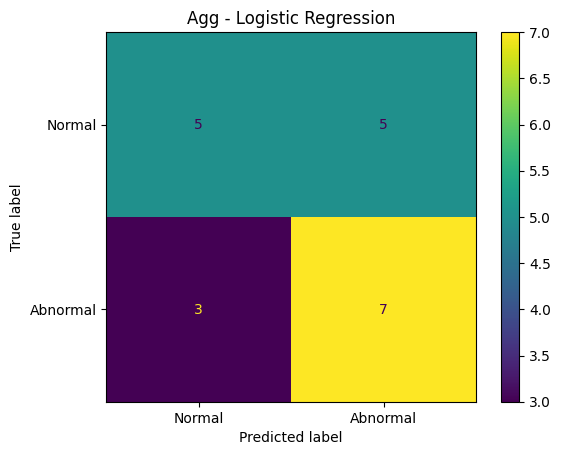

Agg - Decision Tree
Accuracy          : 0.7500
Balanced Accuracy : 0.7500
Precision         : 0.7778
Recall            : 0.7000
F1-score          : 0.7368

              precision    recall  f1-score   support

      Normal       0.73      0.80      0.76        10
    Abnormal       0.78      0.70      0.74        10

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.75      0.75      0.75        20



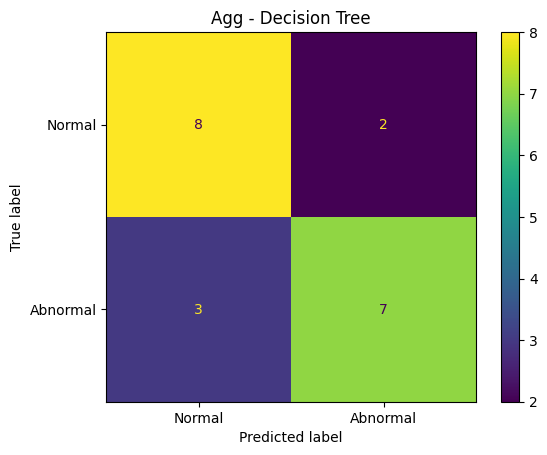

Agg - Random Forest
Accuracy          : 0.6500
Balanced Accuracy : 0.6500
Precision         : 0.6364
Recall            : 0.7000
F1-score          : 0.6667

              precision    recall  f1-score   support

      Normal       0.67      0.60      0.63        10
    Abnormal       0.64      0.70      0.67        10

    accuracy                           0.65        20
   macro avg       0.65      0.65      0.65        20
weighted avg       0.65      0.65      0.65        20



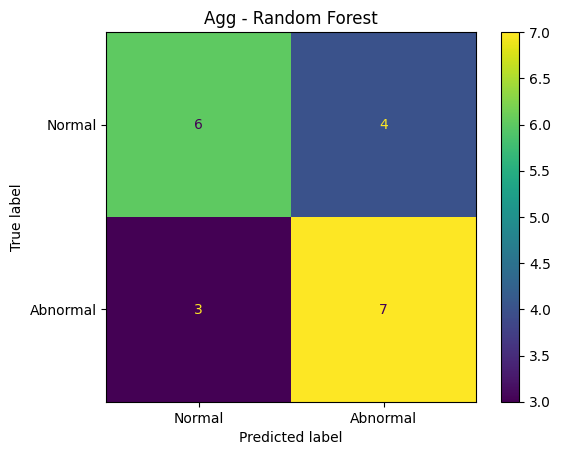

Agg - Extra Trees
Accuracy          : 0.5500
Balanced Accuracy : 0.5500
Precision         : 0.5385
Recall            : 0.7000
F1-score          : 0.6087

              precision    recall  f1-score   support

      Normal       0.57      0.40      0.47        10
    Abnormal       0.54      0.70      0.61        10

    accuracy                           0.55        20
   macro avg       0.55      0.55      0.54        20
weighted avg       0.55      0.55      0.54        20



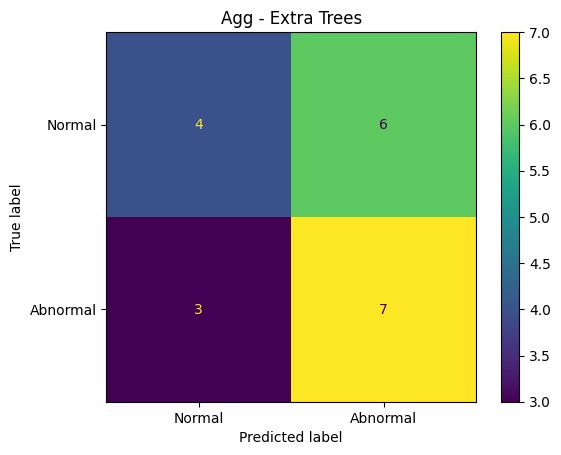

Agg - XGBoost
Accuracy          : 0.6500
Balanced Accuracy : 0.6500
Precision         : 0.6154
Recall            : 0.8000
F1-score          : 0.6957

              precision    recall  f1-score   support

      Normal       0.71      0.50      0.59        10
    Abnormal       0.62      0.80      0.70        10

    accuracy                           0.65        20
   macro avg       0.66      0.65      0.64        20
weighted avg       0.66      0.65      0.64        20



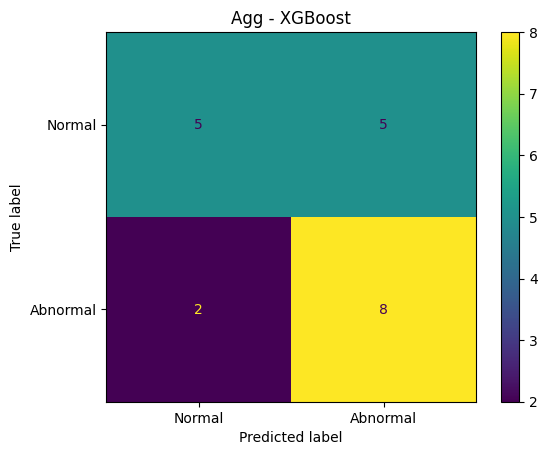

In [36]:
# =========================================================
# 6. 五個模型：Aggregated group-level
# =========================================================

agg_results = []

# 1. Logistic Regression
lr_agg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

lr_agg.fit(X_train_agg, y_train_agg)
agg_results.append(
    evaluate_classifier(lr_agg, X_test_agg, y_test_agg, "Agg - Logistic Regression")
)


# 2. Decision Tree
dt_agg = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42
)

dt_agg.fit(X_train_agg, y_train_agg)
agg_results.append(
    evaluate_classifier(dt_agg, X_test_agg, y_test_agg, "Agg - Decision Tree")
)


# 3. Random Forest
rf_agg = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_agg.fit(X_train_agg, y_train_agg)
agg_results.append(
    evaluate_classifier(rf_agg, X_test_agg, y_test_agg, "Agg - Random Forest")
)


# 4. Extra Trees
et_agg = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_agg.fit(X_train_agg, y_train_agg)
agg_results.append(
    evaluate_classifier(et_agg, X_test_agg, y_test_agg, "Agg - Extra Trees")
)


# 5. XGBoost
neg = np.sum(y_train_agg == 0)
pos = np.sum(y_train_agg == 1)
scale_pos_weight = neg / pos if pos > 0 else 1

xgb_agg = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_agg.fit(X_train_agg, y_train_agg)
agg_results.append(
    evaluate_classifier(xgb_agg, X_test_agg, y_test_agg, "Agg - XGBoost")
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
1,Agg - Decision Tree,0.75,0.75,0.777778,0.7,0.736842
4,Agg - XGBoost,0.65,0.65,0.615385,0.8,0.695652
2,Agg - Random Forest,0.65,0.65,0.636364,0.7,0.666667
0,Agg - Logistic Regression,0.60,0.60,0.583333,0.7,0.636364
3,Agg - Extra Trees,0.55,0.55,0.538462,0.7,0.608696


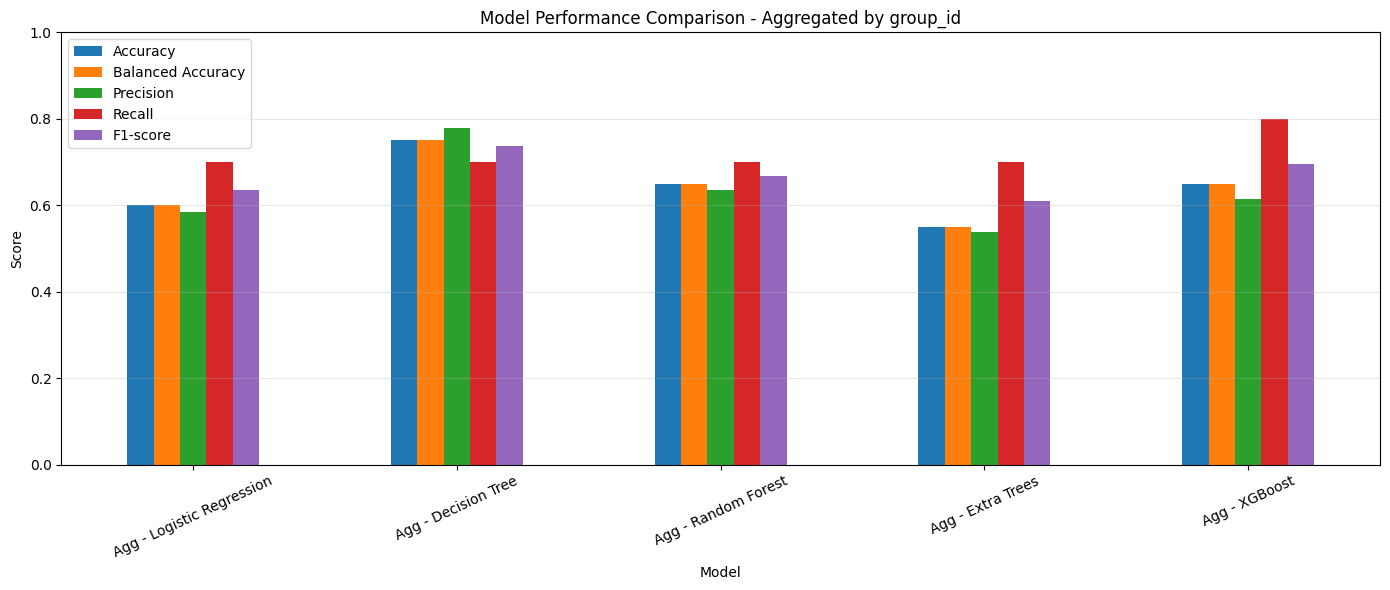

In [37]:
# =========================================================
# 7. Aggregated model comparison
# =========================================================

agg_results_df = pd.DataFrame(agg_results)

display(agg_results_df.sort_values("F1-score", ascending=False))

metrics = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1-score"]

agg_results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(f"Model Performance Comparison - Aggregated by {group_col}")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

,Feature,Importance
0,TIMES_middle_third_mean_median,0.004090
1,TEMP_middle_third_mean_median,0.003871
2,CONDUCTIVITY_last_median,0.003834
3,MANUAL_INPUT_q75_max,0.003821
4,MANUAL_INPUT_q75_std,0.003599
5,TEMP_mean_median,0.003499
6,TEMP_last_third_mean_median,0.003485
7,TIMES_median_median,0.003430
8,UF_median_median,0.003271
9,TEMP_first_third_mean_median,0.003254


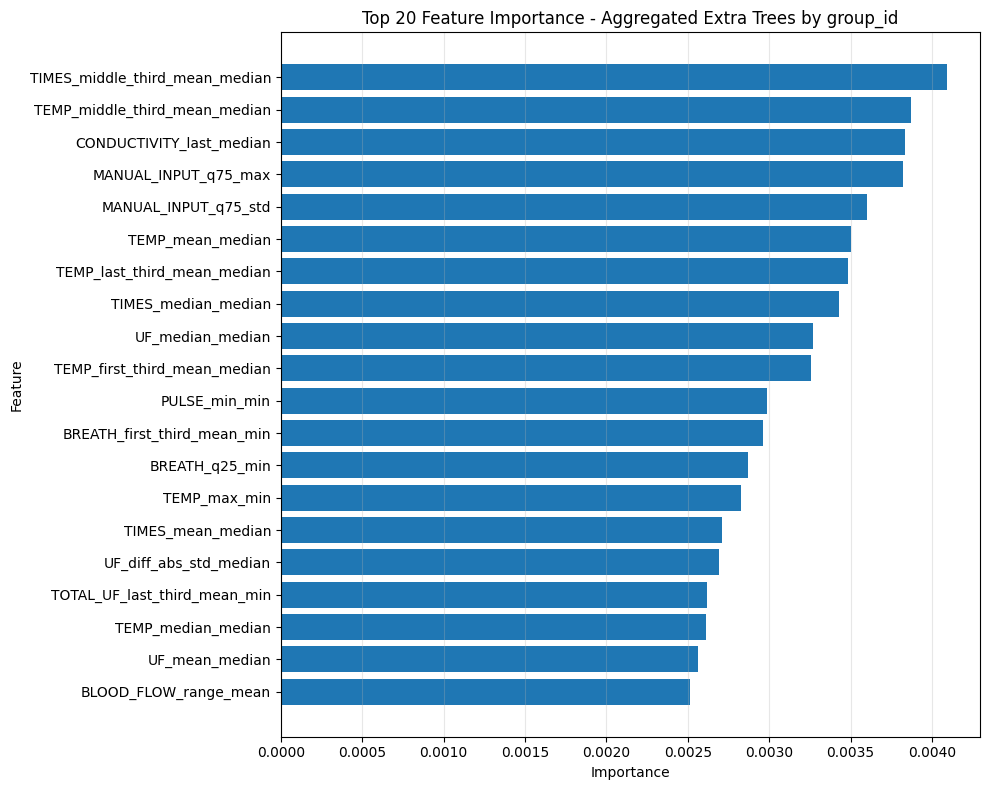

In [38]:
# =========================================================
# 8. Aggregated Extra Trees Feature Importance
# =========================================================

agg_feature_names = X_agg_df.columns.tolist()

et_agg_importance_df = pd.DataFrame({
    "Feature": agg_feature_names,
    "Importance": et_agg.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

display(et_agg_importance_df.head(30))

top_n = 20
top_et_agg = et_agg_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(
    top_et_agg["Feature"][::-1],
    top_et_agg["Importance"][::-1]
)
plt.title(f"Top 20 Feature Importance - Aggregated Extra Trees by {group_col}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Aggregated 五模型 5-Fold Cross Validation

In [39]:
# =========================================================
# Aggregated Group-level：五個模型 5-Fold Cross Validation
# Models:
# 1. Logistic Regression
# 2. Decision Tree
# 3. Random Forest
# 4. Extra Trees
# 5. XGBoost
# =========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier


# =========================================================
# 1. 建立 5-Fold CV
# =========================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}


# =========================================================
# 2. 建立五個模型
# =========================================================

neg = np.sum(y_agg_np == 0)
pos = np.sum(y_agg_np == 1)
scale_pos_weight = neg / pos if pos > 0 else 1

models = {
    "Agg CV - Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]),

    "Agg CV - Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42
    ),

    "Agg CV - Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Agg CV - Extra Trees": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Agg CV - XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=1,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.6,
        gamma=0.5,
        reg_lambda=5.0,
        reg_alpha=0.5,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
        )
}


# =========================================================
# 3. 執行五個模型的 Cross Validation
# =========================================================

cv_results_list = []

for model_name, model in models.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    scores = cross_validate(
        model,
        X_agg,
        y_agg_np,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced Accuracy Std": scores["test_balanced_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1-score Mean": scores["test_f1"].mean(),
        "F1-score Std": scores["test_f1"].std()
    }

    cv_results_list.append(result)

    print(f"Accuracy          : {result['Accuracy Mean']:.4f} +/- {result['Accuracy Std']:.4f}")
    print(f"Balanced Accuracy : {result['Balanced Accuracy Mean']:.4f} +/- {result['Balanced Accuracy Std']:.4f}")
    print(f"Precision         : {result['Precision Mean']:.4f} +/- {result['Precision Std']:.4f}")
    print(f"Recall            : {result['Recall Mean']:.4f} +/- {result['Recall Std']:.4f}")
    print(f"F1-score          : {result['F1-score Mean']:.4f} +/- {result['F1-score Std']:.4f}")


# =========================================================
# 4. 整理成表格
# =========================================================

cv_results_df = pd.DataFrame(cv_results_list)

cv_results_df_sorted = cv_results_df.sort_values(
    by="F1-score Mean",
    ascending=False
).reset_index(drop=True)

display(cv_results_df_sorted)

Agg CV - Logistic Regression
Accuracy          : 0.5750 +/- 0.0468
Balanced Accuracy : 0.5750 +/- 0.0468
Precision         : 0.5811 +/- 0.0546
Recall            : 0.5750 +/- 0.1696
F1-score          : 0.5642 +/- 0.0821
Agg CV - Decision Tree
Accuracy          : 0.5750 +/- 0.0729
Balanced Accuracy : 0.5750 +/- 0.0729
Precision         : 0.5851 +/- 0.0912
Recall            : 0.5750 +/- 0.1696
F1-score          : 0.5669 +/- 0.0908
Agg CV - Random Forest
Accuracy          : 0.6875 +/- 0.1186
Balanced Accuracy : 0.6875 +/- 0.1186
Precision         : 0.6929 +/- 0.1167
Recall            : 0.7000 +/- 0.1696
F1-score          : 0.6870 +/- 0.1171
Agg CV - Extra Trees
Accuracy          : 0.6750 +/- 0.0919
Balanced Accuracy : 0.6750 +/- 0.0919
Precision         : 0.6769 +/- 0.1117
Recall            : 0.7250 +/- 0.0935
F1-score          : 0.6924 +/- 0.0716
Agg CV - XGBoost
Accuracy          : 0.7750 +/- 0.0637
Balanced Accuracy : 0.7750 +/- 0.0637
Precision         : 0.8012 +/- 0.1330
Recall       

,Model,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-score Mean,F1-score Std
0,Agg CV - XGBoost,0.7750,0.063738,0.7750,0.063738,0.801172,0.133006,0.800,0.127475,0.782222,0.046855
1,Agg CV - Extra Trees,0.6750,0.091856,0.6750,0.091856,0.676869,0.111670,0.725,0.093541,0.692376,0.071604
2,Agg CV - Random Forest,0.6875,0.118585,0.6875,0.118585,0.692900,0.116743,0.700,0.169558,0.686951,0.117134
3,Agg CV - Decision Tree,0.5750,0.072887,0.5750,0.072887,0.585073,0.091186,0.575,0.169558,0.566905,0.090803
4,Agg CV - Logistic Regression,0.5750,0.046771,0.5750,0.046771,0.581111,0.054614,0.575,0.169558,0.564240,0.082137


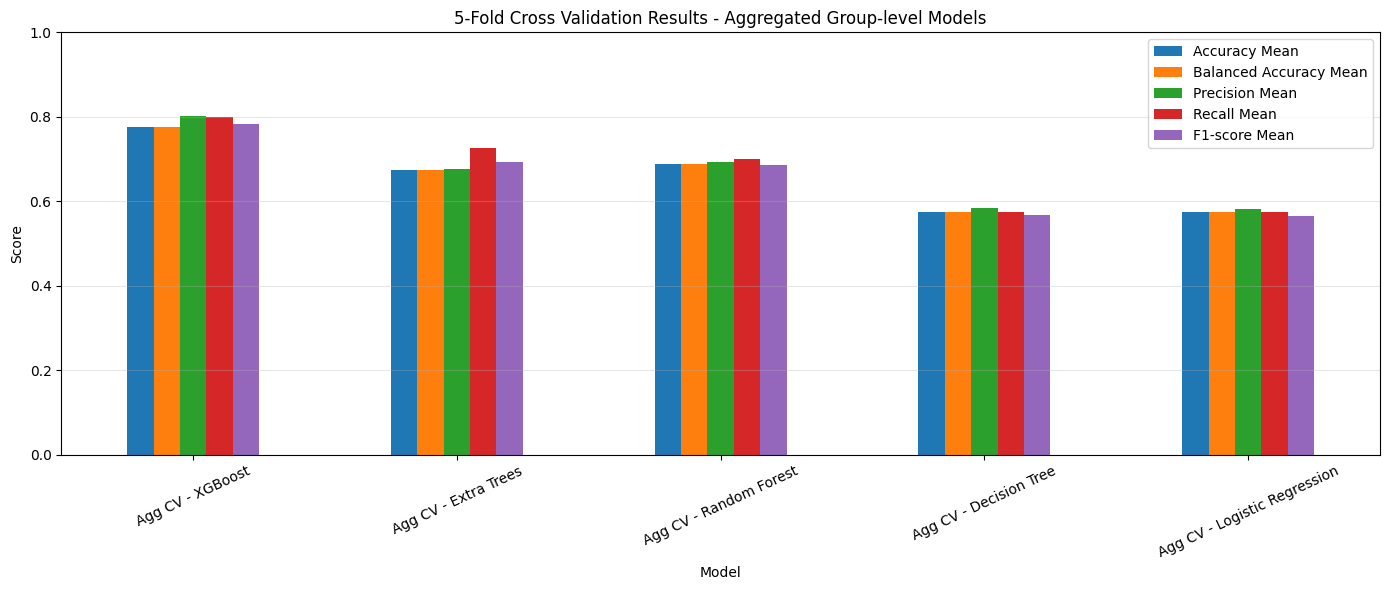

In [40]:
# =========================================================
# 5. 畫 Cross Validation 結果比較圖
# =========================================================

import matplotlib.pyplot as plt

plot_df = cv_results_df_sorted.set_index("Model")[
    [
        "Accuracy Mean",
        "Balanced Accuracy Mean",
        "Precision Mean",
        "Recall Mean",
        "F1-score Mean"
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("5-Fold Cross Validation Results - Aggregated Group-level Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

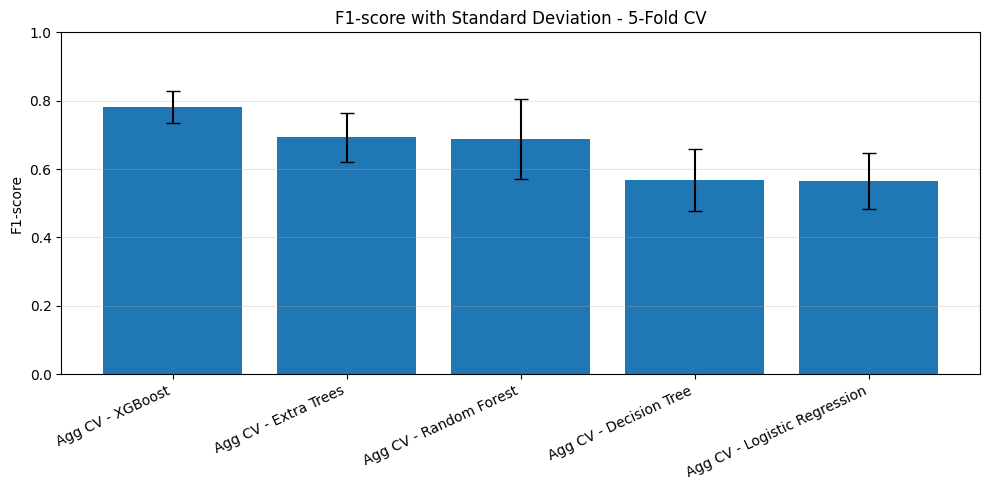

In [41]:
# =========================================================
# 6. F1-score mean ± std
# =========================================================

plt.figure(figsize=(10, 5))

plt.bar(
    cv_results_df_sorted["Model"],
    cv_results_df_sorted["F1-score Mean"],
    yerr=cv_results_df_sorted["F1-score Std"],
    capsize=5
)

plt.title("F1-score with Standard Deviation - 5-Fold CV")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Top-K Feature Selection + XGBoost

,Feature,Importance
0,TEMP_middle_third_mean_median,0.004699
1,CONDUCTIVITY_last_median,0.004635
2,TEMP_mean_median,0.004597
3,MANUAL_INPUT_q75_max,0.004062
4,TIMES_last_std,0.003864
5,TEMP_last_third_mean_median,0.003712
6,CONDUCTIVITY_median_median,0.003661
7,TEMP_median_median,0.003634
8,CONDUCTIVITY_last_third_mean_median,0.003563
9,TEMP_q75_median,0.003501


,Top K,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,15,0.7875,0.063738,0.7875,0.063738,0.813413,0.111863,0.775,0.122474,0.782441,0.069073
1,20,0.7875,0.050000,0.7875,0.050000,0.815296,0.105096,0.775,0.145774,0.780306,0.061825
2,80,0.7625,0.072887,0.7625,0.072887,0.763156,0.091512,0.800,0.150000,0.768277,0.074462
3,30,0.7625,0.061237,0.7625,0.061237,0.757857,0.081217,0.800,0.150000,0.766746,0.071714
4,10,0.7625,0.072887,0.7625,0.072887,0.788632,0.123637,0.775,0.165831,0.761592,0.083039
5,25,0.7500,0.055902,0.7500,0.055902,0.794505,0.138626,0.750,0.136931,0.750261,0.035307
6,40,0.7500,0.039528,0.7500,0.039528,0.796410,0.131332,0.750,0.158114,0.747497,0.027578
7,100,0.7375,0.100000,0.7375,0.100000,0.735775,0.120605,0.775,0.165831,0.743754,0.107049
8,60,0.7375,0.046771,0.7375,0.046771,0.754029,0.086879,0.750,0.136931,0.738571,0.045185
9,50,0.7250,0.030619,0.7250,0.030619,0.749267,0.081588,0.725,0.145774,0.721429,0.033333


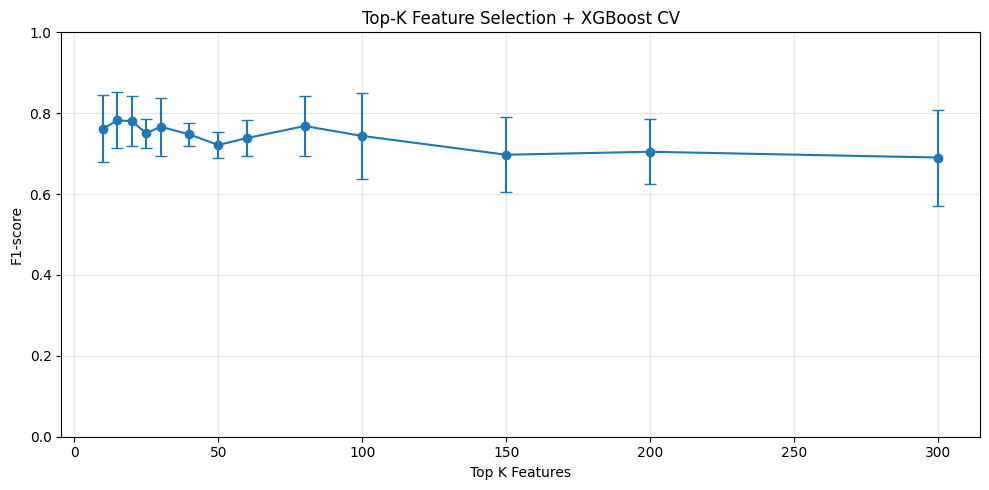

In [42]:
# =========================================================
# Top-K Feature Selection + XGBoost 5-Fold CV
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

from xgboost import XGBClassifier


# 1. 用 Extra Trees 估計 feature importance
selector_model = ExtraTreesClassifier(
    n_estimators=1000,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_agg, y_agg_np)

importance = selector_model.feature_importances_
ranked_idx = np.argsort(importance)[::-1]

agg_feature_names = X_agg_df.columns.tolist()

importance_rank_df = pd.DataFrame({
    "Feature": [agg_feature_names[i] for i in ranked_idx],
    "Importance": importance[ranked_idx]
})

display(importance_rank_df.head(30))


# 2. CV 設定
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

neg = np.sum(y_agg_np == 0)
pos = np.sum(y_agg_np == 1)
scale_pos_weight = neg / pos if pos > 0 else 1


# 3. 測不同 Top-K
k_list = [10, 15, 20, 25, 30, 40, 50, 60, 80, 100, 150, 200, 300]

rows = []

for k in k_list:
    selected_idx = ranked_idx[:k]
    X_sel = X_agg[:, selected_idx]

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X_sel,
        y_agg_np,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    rows.append({
        "Top K": k,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced Accuracy Std": scores["test_balanced_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
    })

topk_results_df = pd.DataFrame(rows).sort_values(
    by="F1 Mean",
    ascending=False
).reset_index(drop=True)

display(topk_results_df)


# 4. 畫圖
plt.figure(figsize=(10, 5))
plt.errorbar(
    topk_results_df.sort_values("Top K")["Top K"],
    topk_results_df.sort_values("Top K")["F1 Mean"],
    yerr=topk_results_df.sort_values("Top K")["F1 Std"],
    marker="o",
    capsize=4
)
plt.title("Top-K Feature Selection + XGBoost CV")
plt.xlabel("Top K Features")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. XGBoost Hyperparameter Search

In [43]:
# =========================================================
# XGBoost Hyperparameter Search with Selected Top-K Features
# =========================================================

best_k = 30   # 你可以改成 30 或 50
selected_idx = ranked_idx[:best_k]
X_sel = X_agg[:, selected_idx]

param_grid = [
    {
        "name": "depth1_strong_reg",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 1,
        "min_child_weight": 2,
        "subsample": 0.8,
        "colsample_bytree": 0.6,
        "gamma": 0.5,
        "reg_lambda": 5.0,
        "reg_alpha": 0.5
    },
    {
        "name": "depth2_default_reg",
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 2,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "gamma": 0.0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0
    },
    {
        "name": "depth2_stronger_reg",
        "n_estimators": 250,
        "learning_rate": 0.04,
        "max_depth": 2,
        "min_child_weight": 2,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "gamma": 0.3,
        "reg_lambda": 3.0,
        "reg_alpha": 0.5
    },
    {
        "name": "depth2_l1_l2",
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_child_weight": 2,
        "subsample": 0.8,
        "colsample_bytree": 0.6,
        "gamma": 0.5,
        "reg_lambda": 5.0,
        "reg_alpha": 1.0
    },
    {
        "name": "depth3_conservative",
        "n_estimators": 400,
        "learning_rate": 0.02,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.8,
        "colsample_bytree": 0.7,
        "gamma": 1.0,
        "reg_lambda": 5.0,
        "reg_alpha": 1.0
    }
]

tune_rows = []

for params in param_grid:
    model = XGBClassifier(
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        min_child_weight=params["min_child_weight"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        gamma=params["gamma"],
        reg_lambda=params["reg_lambda"],
        reg_alpha=params["reg_alpha"],
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        model,
        X_sel,
        y_agg_np,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    tune_rows.append({
        "Setting": params["name"],
        "Top K": best_k,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced Accuracy Std": scores["test_balanced_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),
    })

xgb_tune_df = pd.DataFrame(tune_rows).sort_values(
    by="F1 Mean",
    ascending=False
).reset_index(drop=True)

display(xgb_tune_df)

,Setting,Top K,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,depth1_strong_reg,30,0.7750,0.075000,0.7750,0.075000,0.768791,0.092834,0.825,0.150000,0.783492,0.071788
1,depth2_l1_l2,30,0.7750,0.075000,0.7750,0.075000,0.768791,0.092834,0.825,0.150000,0.783492,0.071788
2,depth2_stronger_reg,30,0.7625,0.061237,0.7625,0.061237,0.764347,0.091759,0.800,0.127475,0.770420,0.055512
3,depth2_default_reg,30,0.7625,0.061237,0.7625,0.061237,0.757857,0.081217,0.800,0.150000,0.766746,0.071714
4,depth3_conservative,30,0.7500,0.111803,0.7500,0.111803,0.745934,0.114889,0.775,0.229129,0.742466,0.146532


## 11. Top-K XGBoost + Threshold Tuning

In [44]:
# =========================================================
# Top-K XGBoost + Threshold Tuning
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier


# 你目前較穩定的設定
best_k = 30
selected_idx = ranked_idx[:best_k]
X_sel = X_agg[:, selected_idx]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

thresholds = np.linspace(0.1, 0.9, 81)

fold_results = []
threshold_records = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y_agg_np), start=1):
    X_train_fold = X_sel[train_idx]
    X_test_fold = X_sel[test_idx]
    y_train_fold = y_agg_np[train_idx]
    y_test_fold = y_agg_np[test_idx]

    neg = np.sum(y_train_fold == 0)
    pos = np.sum(y_train_fold == 1)
    scale_pos_weight = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold)

    proba = model.predict_proba(X_test_fold)[:, 1]

    best_row = None

    for th in thresholds:
        y_pred = (proba >= th).astype(int)

        row = {
            "fold": fold,
            "threshold": th,
            "accuracy": accuracy_score(y_test_fold, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test_fold, y_pred),
            "precision": precision_score(y_test_fold, y_pred, zero_division=0),
            "recall": recall_score(y_test_fold, y_pred, zero_division=0),
            "f1": f1_score(y_test_fold, y_pred, zero_division=0)
        }

        threshold_records.append(row)

        if best_row is None or row["f1"] > best_row["f1"]:
            best_row = row

    fold_results.append(best_row)

threshold_tuning_df = pd.DataFrame(fold_results)
all_threshold_records_df = pd.DataFrame(threshold_records)

print("Best threshold per fold:")
display(threshold_tuning_df)

summary = {
    "Accuracy Mean": threshold_tuning_df["accuracy"].mean(),
    "Accuracy Std": threshold_tuning_df["accuracy"].std(),
    "Balanced Accuracy Mean": threshold_tuning_df["balanced_accuracy"].mean(),
    "Balanced Accuracy Std": threshold_tuning_df["balanced_accuracy"].std(),
    "Precision Mean": threshold_tuning_df["precision"].mean(),
    "Precision Std": threshold_tuning_df["precision"].std(),
    "Recall Mean": threshold_tuning_df["recall"].mean(),
    "Recall Std": threshold_tuning_df["recall"].std(),
    "F1 Mean": threshold_tuning_df["f1"].mean(),
    "F1 Std": threshold_tuning_df["f1"].std(),
    "Avg Best Threshold": threshold_tuning_df["threshold"].mean()
}

threshold_summary_df = pd.DataFrame([summary])
display(threshold_summary_df)

Best threshold per fold:


,fold,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,1,0.78,0.8125,0.8125,0.727273,1.000,0.842105
1,2,0.55,0.7500,0.7500,0.833333,0.625,0.714286
2,3,0.63,0.8750,0.8750,0.875000,0.875,0.875000
3,4,0.30,0.9375,0.9375,0.888889,1.000,0.941176
4,5,0.28,0.9375,0.9375,0.888889,1.000,0.941176


,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std,Avg Best Threshold
0,0.8625,0.08149,0.8625,0.08149,0.842677,0.068413,0.9,0.16298,0.862749,0.093434,0.508


Fold Results: Same Top-30 XGBoost + Threshold Tuning


,Fold,Best Threshold,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,1,0.78,0.8125,0.8125,0.727273,1.000,0.842105
1,2,0.55,0.7500,0.7500,0.833333,0.625,0.714286
2,3,0.63,0.8750,0.8750,0.875000,0.875,0.875000
3,4,0.30,0.9375,0.9375,0.888889,1.000,0.941176
4,5,0.28,0.9375,0.9375,0.888889,1.000,0.941176



Mean Results:


,Mean
Best Threshold,0.508000
Accuracy,0.862500
Balanced Accuracy,0.862500
Precision,0.842677
Recall,0.900000
F1-score,0.862749


Aggregated Confusion Matrix across 5-fold CV
[[33  7]
 [ 4 36]]


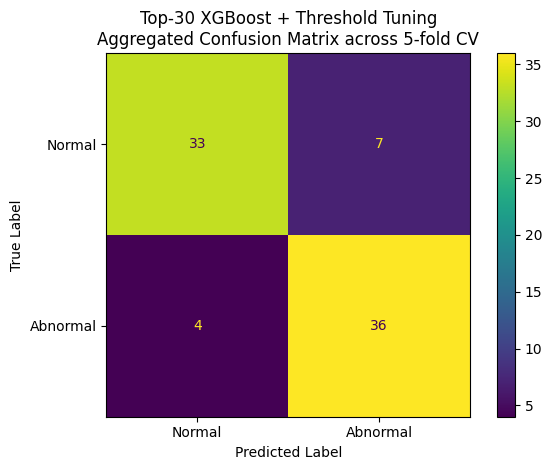

Aggregated Metrics across 5-fold CV


,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,0.8625,0.8625,0.837209,0.9,0.86747


In [47]:
# =========================================================
# Aggregated Confusion Matrix
# 使用與前面 threshold tuning 完全相同的設定
# Top-30 XGBoost + Threshold Tuning
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier


# =========================================================
# 1. 使用前面已經選好的 Top-30 features
# =========================================================

best_k = 30
selected_idx = ranked_idx[:best_k]
X_sel = X_agg[:, selected_idx]

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

thresholds = np.linspace(0.1, 0.9, 81)


# =========================================================
# 2. 儲存每一 fold 的 true label / prediction
# =========================================================

all_y_true = []
all_y_pred = []
fold_cm_results = []


# =========================================================
# 3. 重新跑同一套 threshold tuning，並保存 prediction
# =========================================================

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y_agg_np), start=1):
    X_train_fold = X_sel[train_idx]
    X_test_fold = X_sel[test_idx]
    y_train_fold = y_agg_np[train_idx]
    y_test_fold = y_agg_np[test_idx]

    neg = np.sum(y_train_fold == 0)
    pos = np.sum(y_train_fold == 1)
    scale_pos_weight = neg / pos if pos > 0 else 1

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_fold, y_train_fold)

    proba = model.predict_proba(X_test_fold)[:, 1]

    best_row = None
    best_pred = None

    for th in thresholds:
        y_pred = (proba >= th).astype(int)

        row = {
            "Fold": fold,
            "Best Threshold": th,
            "Accuracy": accuracy_score(y_test_fold, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_test_fold, y_pred),
            "Precision": precision_score(y_test_fold, y_pred, zero_division=0),
            "Recall": recall_score(y_test_fold, y_pred, zero_division=0),
            "F1-score": f1_score(y_test_fold, y_pred, zero_division=0)
        }

        if best_row is None or row["F1-score"] > best_row["F1-score"]:
            best_row = row
            best_pred = y_pred

    all_y_true.extend(y_test_fold)
    all_y_pred.extend(best_pred)
    fold_cm_results.append(best_row)


# =========================================================
# 4. 顯示 fold 結果
# =========================================================

fold_cm_results_df = pd.DataFrame(fold_cm_results)

print("=========================================================")
print("Fold Results: Same Top-30 XGBoost + Threshold Tuning")
print("=========================================================")
display(fold_cm_results_df)

print("\nMean Results:")
display(fold_cm_results_df.drop(columns=["Fold"]).mean().to_frame("Mean"))


# =========================================================
# 5. Aggregated Confusion Matrix
# =========================================================

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_true, all_y_pred)

print("=========================================================")
print("Aggregated Confusion Matrix across 5-fold CV")
print("=========================================================")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Abnormal"]
)

disp.plot(values_format="d")
plt.title("Top-30 XGBoost + Threshold Tuning\nAggregated Confusion Matrix across 5-fold CV")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("top30_xgboost_threshold_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


# =========================================================
# 6. Aggregated Metrics
# =========================================================

agg_metrics = {
    "Accuracy": accuracy_score(all_y_true, all_y_pred),
    "Balanced Accuracy": balanced_accuracy_score(all_y_true, all_y_pred),
    "Precision": precision_score(all_y_true, all_y_pred, zero_division=0),
    "Recall": recall_score(all_y_true, all_y_pred, zero_division=0),
    "F1-score": f1_score(all_y_true, all_y_pred, zero_division=0)
}

agg_metrics_df = pd.DataFrame([agg_metrics])

print("=========================================================")
print("Aggregated Metrics across 5-fold CV")
print("=========================================================")
display(agg_metrics_df)

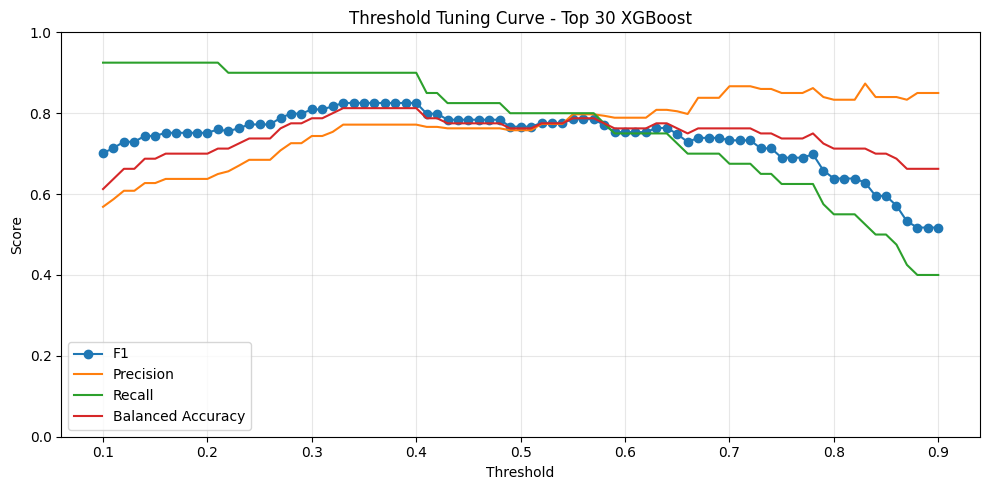

In [48]:
# =========================================================
# Plot threshold vs F1
# =========================================================

threshold_curve = all_threshold_records_df.groupby("threshold").agg({
    "f1": ["mean", "std"],
    "precision": "mean",
    "recall": "mean",
    "balanced_accuracy": "mean"
})

threshold_curve.columns = [
    "f1_mean",
    "f1_std",
    "precision_mean",
    "recall_mean",
    "balanced_accuracy_mean"
]

threshold_curve = threshold_curve.reset_index()

plt.figure(figsize=(10, 5))
plt.plot(threshold_curve["threshold"], threshold_curve["f1_mean"], marker="o", label="F1")
plt.plot(threshold_curve["threshold"], threshold_curve["precision_mean"], label="Precision")
plt.plot(threshold_curve["threshold"], threshold_curve["recall_mean"], label="Recall")
plt.plot(threshold_curve["threshold"], threshold_curve["balanced_accuracy_mean"], label="Balanced Accuracy")

plt.title("Threshold Tuning Curve - Top 30 XGBoost")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 12. MIL-like Probability Aggregation

先在 session-level 預測 probability，再把同一 group 的 session probabilities 聚合成 group-level 預測。

In [49]:
# =========================================================
# MIL-like Probability Aggregation
# Session-level prediction -> Group-level prediction
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# 建立 group label
group_col = "group_id"

session_df_for_mil = pd.DataFrame({
    "group_id": session_meta_df[group_col].values,
    "label": y
})

group_labels = session_df_for_mil.groupby("group_id")["label"].first()
unique_groups = group_labels.index.values
y_group = group_labels.values

print("Groups:", len(unique_groups))
print("Group label distribution:")
print(pd.Series(y_group).value_counts())


# 以 group 為單位做 CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

mil_rows = []

for fold, (train_group_idx, test_group_idx) in enumerate(cv.split(unique_groups, y_group), start=1):
    train_groups = unique_groups[train_group_idx]
    test_groups = unique_groups[test_group_idx]

    train_mask = session_df_for_mil["group_id"].isin(train_groups).values
    test_mask = session_df_for_mil["group_id"].isin(test_groups).values

    X_train_s = stats_X[train_mask]
    y_train_s = y[train_mask]

    X_test_s = stats_X[test_mask]
    y_test_s = y[test_mask]

    test_group_ids = session_df_for_mil.loc[test_mask, "group_id"].values

    neg = np.sum(y_train_s == 0)
    pos = np.sum(y_train_s == 1)
    scale_pos_weight = neg / pos if pos > 0 else 1

    # session-level model
    session_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    session_model.fit(X_train_s, y_train_s)

    session_proba = session_model.predict_proba(X_test_s)[:, 1]

    pred_df = pd.DataFrame({
        "group_id": test_group_ids,
        "proba": session_proba
    })

    # group-level true label
    true_group_label = group_labels.loc[test_groups]

    # 不同聚合方式
    group_pred_features = []

    for gid, g in pred_df.groupby("group_id"):
        probs = np.sort(g["proba"].values)[::-1]

        group_pred_features.append({
            "group_id": gid,
            "mean_proba": np.mean(probs),
            "max_proba": np.max(probs),
            "top3_mean_proba": np.mean(probs[:min(3, len(probs))]),
            "top5_mean_proba": np.mean(probs[:min(5, len(probs))]),
            "num_sessions": len(probs)
        })

    group_pred_df = pd.DataFrame(group_pred_features).set_index("group_id")
    group_pred_df["true_label"] = true_group_label.loc[group_pred_df.index].values

    # 對每種 aggregation 和 threshold 評估
    agg_methods = ["mean_proba", "max_proba", "top3_mean_proba", "top5_mean_proba"]
    thresholds = np.linspace(0.1, 0.9, 81)

    for method in agg_methods:
        for th in thresholds:
            y_true_g = group_pred_df["true_label"].values
            y_pred_g = (group_pred_df[method].values >= th).astype(int)

            mil_rows.append({
                "fold": fold,
                "method": method,
                "threshold": th,
                "accuracy": accuracy_score(y_true_g, y_pred_g),
                "balanced_accuracy": balanced_accuracy_score(y_true_g, y_pred_g),
                "precision": precision_score(y_true_g, y_pred_g, zero_division=0),
                "recall": recall_score(y_true_g, y_pred_g, zero_division=0),
                "f1": f1_score(y_true_g, y_pred_g, zero_division=0)
            })

mil_results_df = pd.DataFrame(mil_rows)

display(mil_results_df.head())

Groups: 80
Group label distribution:
0    40
1    40
Name: count, dtype: int64


,fold,method,threshold,accuracy,balanced_accuracy,precision,recall,f1
0,1,mean_proba,0.10,0.5,0.5,0.5,1.0,0.666667
1,1,mean_proba,0.11,0.5,0.5,0.5,1.0,0.666667
2,1,mean_proba,0.12,0.5,0.5,0.5,1.0,0.666667
3,1,mean_proba,0.13,0.5,0.5,0.5,1.0,0.666667
4,1,mean_proba,0.14,0.5,0.5,0.5,1.0,0.666667


In [50]:
# =========================================================
# Summarize MIL-like aggregation results
# =========================================================

mil_summary = mil_results_df.groupby(["method", "threshold"]).agg({
    "accuracy": ["mean", "std"],
    "balanced_accuracy": ["mean", "std"],
    "precision": ["mean", "std"],
    "recall": ["mean", "std"],
    "f1": ["mean", "std"]
}).reset_index()

mil_summary.columns = [
    "method",
    "threshold",
    "Accuracy Mean",
    "Accuracy Std",
    "Balanced Accuracy Mean",
    "Balanced Accuracy Std",
    "Precision Mean",
    "Precision Std",
    "Recall Mean",
    "Recall Std",
    "F1 Mean",
    "F1 Std"
]

mil_summary_sorted = mil_summary.sort_values(
    by="F1 Mean",
    ascending=False
).reset_index(drop=True)

display(mil_summary_sorted.head(20))

,method,threshold,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
0,mean_proba,0.43,0.7000,0.120221,0.7000,0.120221,0.663384,0.126053,0.850,0.136931,0.740015,0.107782
1,top5_mean_proba,0.67,0.7125,0.071261,0.7125,0.071261,0.675584,0.054811,0.825,0.142522,0.738012,0.075164
2,max_proba,0.72,0.7000,0.027951,0.7000,0.027951,0.660480,0.043743,0.850,0.136931,0.736007,0.042500
3,top5_mean_proba,0.68,0.7125,0.071261,0.7125,0.071261,0.685685,0.069424,0.800,0.111803,0.734297,0.068933
4,mean_proba,0.44,0.7000,0.102698,0.7000,0.102698,0.672540,0.118859,0.825,0.142522,0.733203,0.090869
5,mean_proba,0.42,0.6875,0.116927,0.6875,0.116927,0.653127,0.127793,0.850,0.136931,0.732396,0.103752
6,max_proba,0.74,0.7125,0.034233,0.7125,0.034233,0.699873,0.085427,0.800,0.167705,0.731495,0.043573
7,mean_proba,0.36,0.6500,0.055902,0.6500,0.055902,0.596760,0.040204,0.950,0.068465,0.731261,0.032228
8,mean_proba,0.37,0.6500,0.055902,0.6500,0.055902,0.596760,0.040204,0.950,0.068465,0.731261,0.032228
9,mean_proba,0.35,0.6500,0.055902,0.6500,0.055902,0.596760,0.040204,0.950,0.068465,0.731261,0.032228


,method,threshold,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1 Mean,F1 Std
114,mean_proba,0.43,0.7000,0.120221,0.7000,0.120221,0.663384,0.126053,0.850,0.136931,0.740015,0.107782
300,top5_mean_proba,0.67,0.7125,0.071261,0.7125,0.071261,0.675584,0.054811,0.825,0.142522,0.738012,0.075164
62,max_proba,0.72,0.7000,0.027951,0.7000,0.027951,0.660480,0.043743,0.850,0.136931,0.736007,0.042500
219,top3_mean_proba,0.67,0.6625,0.071261,0.6625,0.071261,0.619545,0.050617,0.875,0.153093,0.718867,0.064379


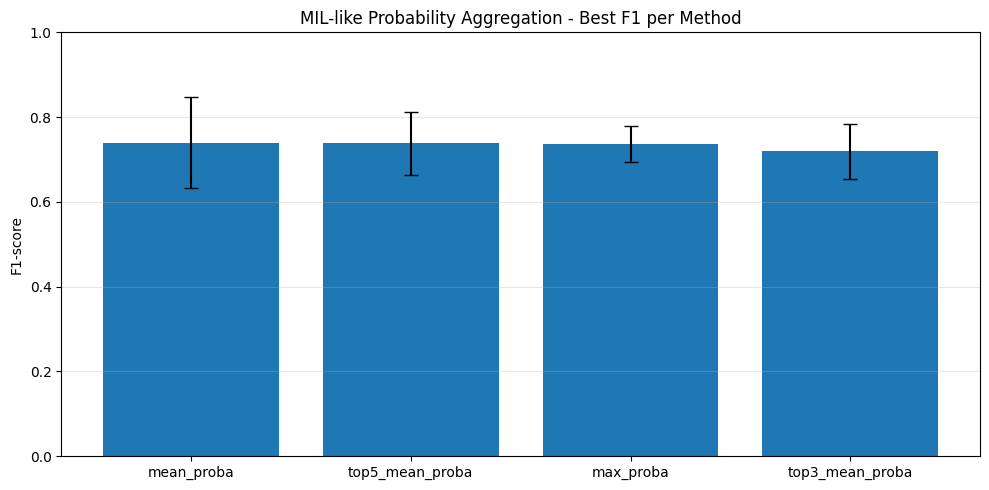

In [51]:
# =========================================================
# Plot MIL method comparison
# =========================================================

best_each_method = mil_summary.sort_values("F1 Mean", ascending=False).groupby("method").head(1)
best_each_method = best_each_method.sort_values("F1 Mean", ascending=False)

display(best_each_method)

plt.figure(figsize=(10, 5))
plt.bar(
    best_each_method["method"],
    best_each_method["F1 Mean"],
    yerr=best_each_method["F1 Std"],
    capsize=5
)

plt.title("MIL-like Probability Aggregation - Best F1 per Method")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Optional：High-confidence Mixed Label 補充實驗

這段不是 folder 主實驗，而是用於分析 folder label 噪音：保留 `folder` 與近似 `rule` 一致的 high-confidence sessions。

In [52]:
# =========================================================
# Mixed label without df_all
# 使用已經萃取好的 stats_X + feature_names 建立 folder + rule 高可信標籤
# =========================================================

import numpy as np
import pandas as pd

# 轉成 DataFrame，比較好取欄位
stats_df = pd.DataFrame(stats_X, columns=feature_names)

# 取得 folder label
# 你的 session_meta_df 裡有 original_file_label / label
if "original_file_label" in session_meta_df.columns:
    folder_label = session_meta_df["original_file_label"].astype(int).values
elif "folder_label" in session_meta_df.columns:
    folder_label = session_meta_df["folder_label"].astype(int).values
elif "label" in session_meta_df.columns:
    folder_label = session_meta_df["label"].astype(int).values
else:
    raise ValueError("session_meta_df 裡找不到 folder label 欄位")

# 檢查必要特徵是否存在
required_cols = [
    "MAX_BLOOD_min",
    "MAX_BLOOD_first_third_mean",
    "MIN_BLOOD_min"
]

for col in required_cols:
    if col not in stats_df.columns:
        raise ValueError(f"找不到必要特徵：{col}")

# 如果你前面已經有這些常數，就用原本的
# 如果沒有，就給預設值
try:
    LOW_THRESHOLD
except NameError:
    LOW_THRESHOLD = 90

try:
    DROP_THRESHOLD
except NameError:
    DROP_THRESHOLD = 30

try:
    DBP_LOW_THRESHOLD
except NameError:
    DBP_LOW_THRESHOLD = 50

# =========================================================
# 建立近似 rule label
# =========================================================

sbp_min = stats_df["MAX_BLOOD_min"].values
sbp_baseline_approx = stats_df["MAX_BLOOD_first_third_mean"].values
sbp_drop = sbp_baseline_approx - sbp_min

dbp_min = stats_df["MIN_BLOOD_min"].values

rule_a = sbp_min < LOW_THRESHOLD
rule_b = sbp_drop >= DROP_THRESHOLD
rule_c = dbp_min < DBP_LOW_THRESHOLD

rule_label = ((rule_a & rule_b) | (rule_a & rule_c)).astype(int)

# =========================================================
# 建立 mixed label
# high-confidence abnormal:
# folder = 1 且 rule = 1
#
# high-confidence normal:
# folder = 0 且 rule = 0
#
# 其他：
# uncertain，排除
# =========================================================

mixed_label = np.full(len(folder_label), -1)

mixed_label[(folder_label == 1) & (rule_label == 1)] = 1
mixed_label[(folder_label == 0) & (rule_label == 0)] = 0

keep_mask = mixed_label != -1

stats_X_mixed = stats_X[keep_mask]
y_mixed = mixed_label[keep_mask]
groups_mixed = session_meta_df.loc[keep_mask, "group_id"].values

session_meta_mixed_df = session_meta_df.loc[keep_mask].copy()
session_meta_mixed_df["folder_label"] = folder_label[keep_mask]
session_meta_mixed_df["rule_label"] = rule_label[keep_mask]
session_meta_mixed_df["mixed_label"] = y_mixed
session_meta_mixed_df["label"] = y_mixed

print("Original sessions:", len(stats_X))
print("Kept mixed sessions:", len(stats_X_mixed))
print("Removed uncertain sessions:", np.sum(~keep_mask))

print("\nFolder label distribution:")
print(pd.Series(folder_label).value_counts())

print("\nRule label distribution:")
print(pd.Series(rule_label).value_counts())

print("\nMixed label distribution:")
print(pd.Series(y_mixed).value_counts())

print("\nFolder vs Rule crosstab:")
display(pd.crosstab(
    folder_label,
    rule_label,
    rownames=["folder_label"],
    colnames=["rule_label"]
))

print("\nKept mixed folder vs rule crosstab:")
display(pd.crosstab(
    session_meta_mixed_df["folder_label"],
    session_meta_mixed_df["rule_label"],
    rownames=["folder_label"],
    colnames=["rule_label"]
))

display(session_meta_mixed_df.head())

Original sessions: 6279
Kept mixed sessions: 2955
Removed uncertain sessions: 3324

Folder label distribution:
1    3748
0    2531
Name: count, dtype: int64

Rule label distribution:
0    5457
1     822
Name: count, dtype: int64

Mixed label distribution:
0    2332
1     623
Name: count, dtype: int64

Folder vs Rule crosstab:


rule_label,0,1
folder_label,,
0,2332,199
1,3125,623



Kept mixed folder vs rule crosstab:


rule_label,0,1
folder_label,,
0,2332,0
1,0,623


,source_folder,file_name,original_file_label,label,session_id,patient_no,start_time,end_time,length,group_id,folder_label,rule_label,mixed_label
4,掉血壓名單,01.xls,1,1,01.xls_S00077,1,2016-05-09 07:39:42,2016-05-09 12:05:41,30,掉血壓名單_01.xls_1,1,1,1
43,掉血壓名單,01.xls,1,1,01.xls_S00707,2,2016-05-18 08:09:56,2016-05-18 12:18:01,31,掉血壓名單_01.xls_2,1,1,1
44,掉血壓名單,01.xls,1,1,01.xls_S00736,2,2016-07-29 08:08:34,2016-07-29 12:07:38,31,掉血壓名單_01.xls_2,1,1,1
49,掉血壓名單,01.xls,1,1,01.xls_S00797,2,2016-12-21 08:13:12,2016-12-21 11:40:26,36,掉血壓名單_01.xls_2,1,1,1
51,掉血壓名單,01.xls,1,1,01.xls_S00815,2,2017-02-01 08:07:40,2017-02-01 11:39:18,41,掉血壓名單_01.xls_2,1,1,1


In [53]:
# =========================================================
# Mixed label group-aware split
# =========================================================

from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(stats_X_mixed, y_mixed, groups=groups_mixed)
)

X_train_m = stats_X_mixed[train_idx]
X_test_m = stats_X_mixed[test_idx]
y_train_m = y_mixed[train_idx]
y_test_m = y_mixed[test_idx]

groups_train_m = groups_mixed[train_idx]
groups_test_m = groups_mixed[test_idx]

print("Train sessions:", X_train_m.shape)
print("Test sessions :", X_test_m.shape)

print("\nTrain label counts:")
print(pd.Series(y_train_m).value_counts())

print("\nTest label counts:")
print(pd.Series(y_test_m).value_counts())

print("\nTrain groups:", len(set(groups_train_m)))
print("Test groups :", len(set(groups_test_m)))
print("Group overlap:", len(set(groups_train_m) & set(groups_test_m)))

Train sessions: (2605, 328)
Test sessions : (350, 328)

Train label counts:
0    2041
1     564
Name: count, dtype: int64

Test label counts:
0    291
1     59
Name: count, dtype: int64

Train groups: 50
Test groups : 13
Group overlap: 0


In [54]:
# =========================================================
# Build feature names for mixed dataset
# =========================================================

feature_names_mixed = build_stat_feature_names(all_feature_columns)

print("stats_X_mixed shape:", stats_X_mixed.shape)
print("feature_names_mixed 數量:", len(feature_names_mixed))

assert len(feature_names_mixed) == stats_X_mixed.shape[1], \
    f"feature_names 數量 {len(feature_names_mixed)} != stats_X_mixed 欄位數 {stats_X_mixed.shape[1]}"

print("✅ feature_names_mixed 與 stats_X_mixed 維度一致")

stats_X_mixed shape: (2955, 328)
feature_names_mixed 數量: 328
✅ feature_names_mixed 與 stats_X_mixed 維度一致


Mixed - Logistic Regression
Accuracy          : 0.9800
Balanced Accuracy : 0.9609
Precision         : 0.9483
Recall            : 0.9322
F1-score          : 0.9402

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       291
    Abnormal       0.95      0.93      0.94        59

    accuracy                           0.98       350
   macro avg       0.97      0.96      0.96       350
weighted avg       0.98      0.98      0.98       350



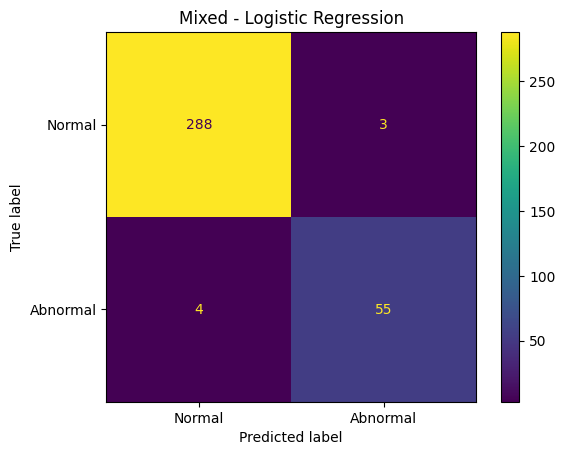

Mixed - Decision Tree
Accuracy          : 0.9800
Balanced Accuracy : 0.9677
Precision         : 0.9333
Recall            : 0.9492
F1-score          : 0.9412

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       291
    Abnormal       0.93      0.95      0.94        59

    accuracy                           0.98       350
   macro avg       0.96      0.97      0.96       350
weighted avg       0.98      0.98      0.98       350



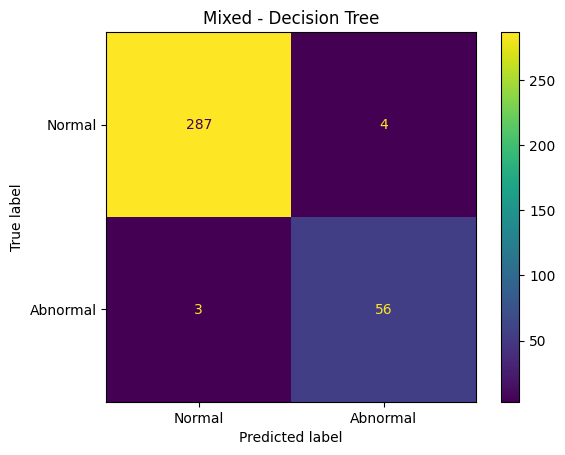

Mixed - Random Forest
Accuracy          : 0.9857
Balanced Accuracy : 0.9779
Precision         : 0.9500
Recall            : 0.9661
F1-score          : 0.9580

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99       291
    Abnormal       0.95      0.97      0.96        59

    accuracy                           0.99       350
   macro avg       0.97      0.98      0.97       350
weighted avg       0.99      0.99      0.99       350



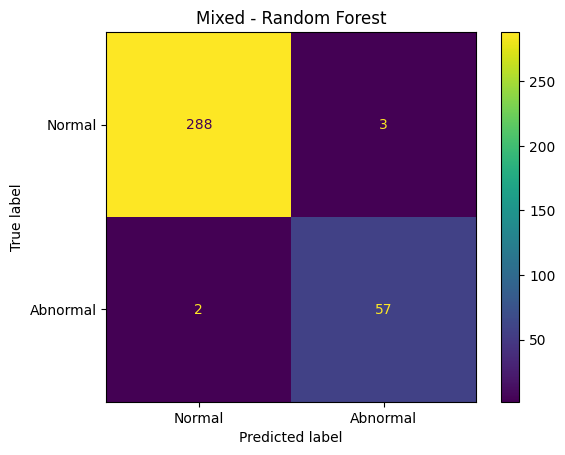

Mixed - Extra Trees
Accuracy          : 0.9714
Balanced Accuracy : 0.9423
Precision         : 0.9298
Recall            : 0.8983
F1-score          : 0.9138

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       291
    Abnormal       0.93      0.90      0.91        59

    accuracy                           0.97       350
   macro avg       0.95      0.94      0.95       350
weighted avg       0.97      0.97      0.97       350



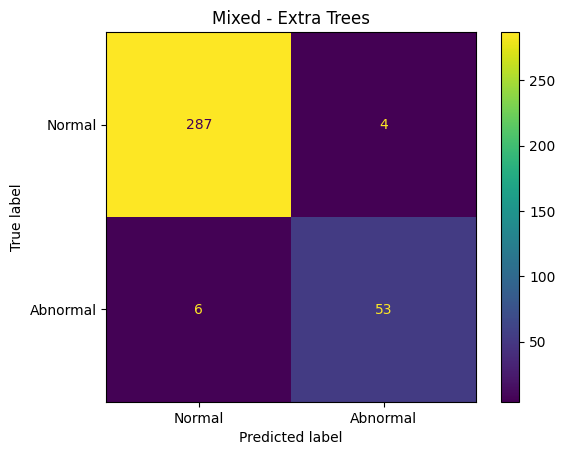

Mixed - XGBoost
Accuracy          : 0.9914
Balanced Accuracy : 0.9948
Precision         : 0.9516
Recall            : 1.0000
F1-score          : 0.9752

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       291
    Abnormal       0.95      1.00      0.98        59

    accuracy                           0.99       350
   macro avg       0.98      0.99      0.99       350
weighted avg       0.99      0.99      0.99       350



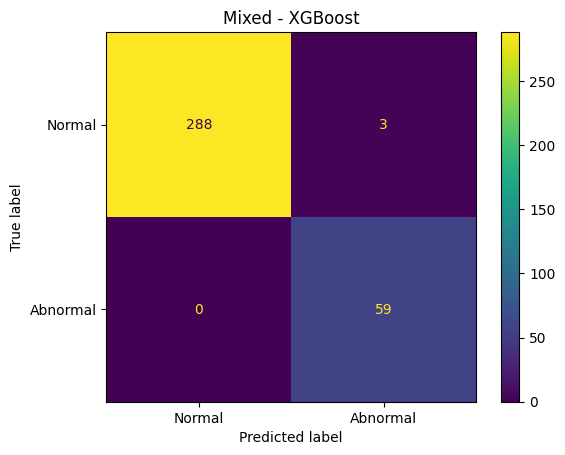

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Mixed - XGBoost,0.991429,0.994845,0.951613,1.000000,0.975207
1,Mixed - Random Forest,0.985714,0.977896,0.950000,0.966102,0.957983
2,Mixed - Decision Tree,0.980000,0.967703,0.933333,0.949153,0.941176
3,Mixed - Logistic Regression,0.980000,0.960947,0.948276,0.932203,0.940171
4,Mixed - Extra Trees,0.971429,0.942280,0.929825,0.898305,0.913793


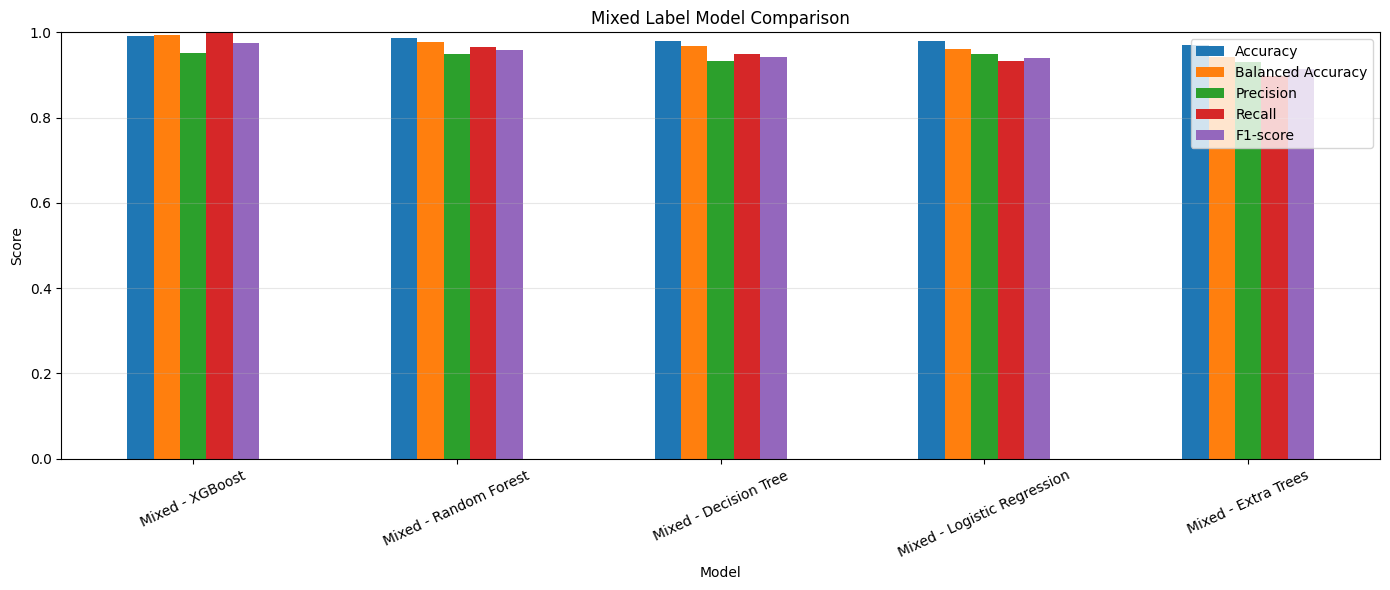

In [55]:
# =========================================================
# Mixed label - 5 models
# Logistic Regression / Decision Tree / Random Forest / Extra Trees / XGBoost
# =========================================================

!pip install xgboost -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


def evaluate_classifier(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    ba = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"Accuracy          : {acc:.4f}")
    print(f"Balanced Accuracy : {ba:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"F1-score          : {f1:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Abnormal"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Abnormal"]
    ).plot()
    plt.title(model_name)
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Balanced Accuracy": ba,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }


mixed_results = []

# Logistic Regression
lr_mixed = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

lr_mixed.fit(X_train_m, y_train_m)
mixed_results.append(
    evaluate_classifier(lr_mixed, X_test_m, y_test_m, "Mixed - Logistic Regression")
)


# Decision Tree
dt_mixed = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

dt_mixed.fit(X_train_m, y_train_m)
mixed_results.append(
    evaluate_classifier(dt_mixed, X_test_m, y_test_m, "Mixed - Decision Tree")
)


# Random Forest
rf_mixed = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_mixed.fit(X_train_m, y_train_m)
mixed_results.append(
    evaluate_classifier(rf_mixed, X_test_m, y_test_m, "Mixed - Random Forest")
)


# Extra Trees
et_mixed = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_mixed.fit(X_train_m, y_train_m)
mixed_results.append(
    evaluate_classifier(et_mixed, X_test_m, y_test_m, "Mixed - Extra Trees")
)


# XGBoost
neg = np.sum(y_train_m == 0)
pos = np.sum(y_train_m == 1)
scale_pos_weight = neg / pos if pos > 0 else 1

xgb_mixed = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_mixed.fit(X_train_m, y_train_m)
mixed_results.append(
    evaluate_classifier(xgb_mixed, X_test_m, y_test_m, "Mixed - XGBoost")
)


mixed_results_df = pd.DataFrame(mixed_results).sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

display(mixed_results_df)

metrics = ["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1-score"]

mixed_results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Mixed Label Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
# =========================================================
# Mixed label leakage control:
# Remove rule-related features: MAX_BLOOD / MIN_BLOOD
# =========================================================

rule_keywords = ["MAX_BLOOD", "MIN_BLOOD"]

rule_related_indices = [
    i for i, name in enumerate(feature_names_mixed)
    if any(keyword in name for keyword in rule_keywords)
]

remove_rule_indices = [
    i for i in range(X_train_m.shape[1])
    if i not in rule_related_indices
]

print("全部特徵數:", X_train_m.shape[1])
print("Rule-related 特徵數:", len(rule_related_indices))
print("移除後特徵數:", len(remove_rule_indices))

print("\n被移除的前 40 個 rule-related 特徵：")
for name in [feature_names_mixed[i] for i in rule_related_indices[:40]]:
    print(name)

X_train_m_no_rule = X_train_m[:, remove_rule_indices]
X_test_m_no_rule = X_test_m[:, remove_rule_indices]

全部特徵數: 328
Rule-related 特徵數: 39
移除後特徵數: 289

被移除的前 40 個 rule-related 特徵：
MAX_BLOOD_mean
MIN_BLOOD_mean
MAX_BLOOD_std
MIN_BLOOD_std
MAX_BLOOD_min
MIN_BLOOD_min
MAX_BLOOD_max
MIN_BLOOD_max
MAX_BLOOD_median
MIN_BLOOD_median
MAX_BLOOD_q25
MIN_BLOOD_q25
MAX_BLOOD_q75
MIN_BLOOD_q75
MAX_BLOOD_range
MIN_BLOOD_range
MAX_BLOOD_first
MIN_BLOOD_first
MAX_BLOOD_last
MIN_BLOOD_last
MAX_BLOOD_delta
MIN_BLOOD_delta
MAX_BLOOD_diff_abs_mean
MIN_BLOOD_diff_abs_mean
MAX_BLOOD_diff_abs_std
MIN_BLOOD_diff_abs_std
MAX_BLOOD_first_third_mean
MIN_BLOOD_first_third_mean
MAX_BLOOD_middle_third_mean
MIN_BLOOD_middle_third_mean
MAX_BLOOD_last_third_mean
MIN_BLOOD_last_third_mean
MAX_BLOOD_slope
MIN_BLOOD_slope
MIN_BLOOD_special_min
MIN_BLOOD_special_max
MIN_BLOOD_special_delta
MIN_BLOOD_special_drop_from_start
MIN_BLOOD_special_min_position


Mixed NoRule - Logistic Regression
Accuracy          : 0.8829
Balanced Accuracy : 0.7877
Precision         : 0.6552
Recall            : 0.6441
F1-score          : 0.6496

              precision    recall  f1-score   support

      Normal       0.93      0.93      0.93       291
    Abnormal       0.66      0.64      0.65        59

    accuracy                           0.88       350
   macro avg       0.79      0.79      0.79       350
weighted avg       0.88      0.88      0.88       350



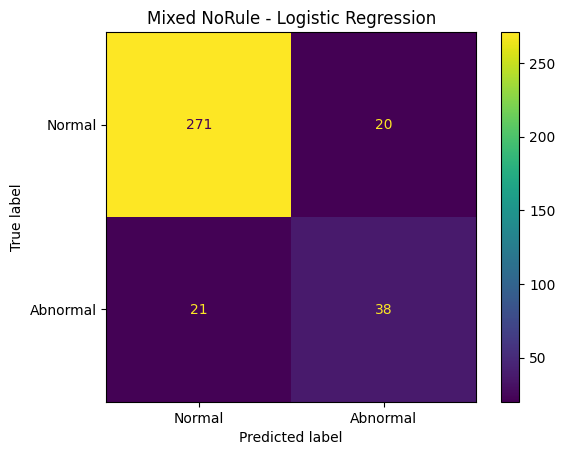

Mixed NoRule - Decision Tree
Accuracy          : 0.9114
Balanced Accuracy : 0.8454
Precision         : 0.7333
Recall            : 0.7458
F1-score          : 0.7395

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       291
    Abnormal       0.73      0.75      0.74        59

    accuracy                           0.91       350
   macro avg       0.84      0.85      0.84       350
weighted avg       0.91      0.91      0.91       350



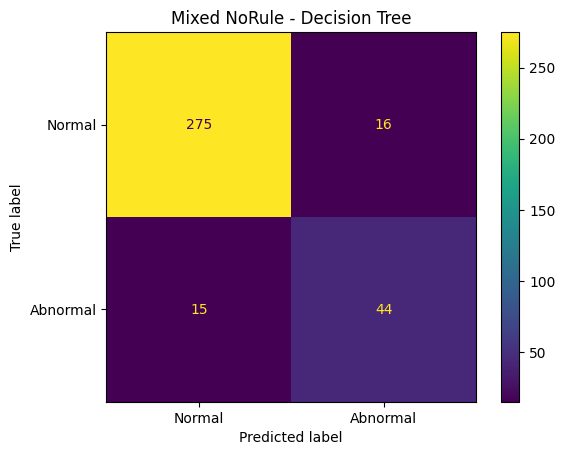

Mixed NoRule - Random Forest
Accuracy          : 0.9200
Balanced Accuracy : 0.7965
Precision         : 0.8780
Recall            : 0.6102
F1-score          : 0.7200

              precision    recall  f1-score   support

      Normal       0.93      0.98      0.95       291
    Abnormal       0.88      0.61      0.72        59

    accuracy                           0.92       350
   macro avg       0.90      0.80      0.84       350
weighted avg       0.92      0.92      0.91       350



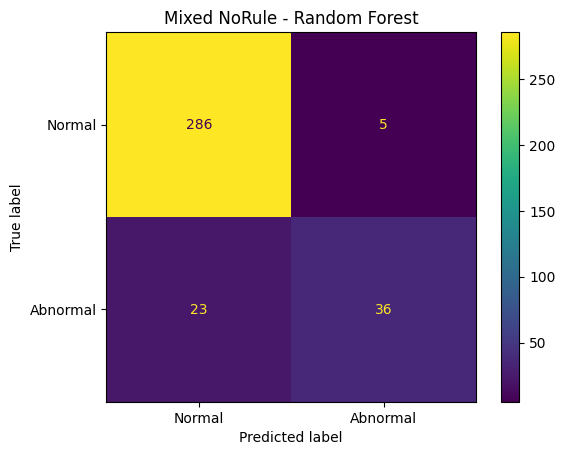

Mixed NoRule - Extra Trees
Accuracy          : 0.9200
Balanced Accuracy : 0.7897
Precision         : 0.8974
Recall            : 0.5932
F1-score          : 0.7143

              precision    recall  f1-score   support

      Normal       0.92      0.99      0.95       291
    Abnormal       0.90      0.59      0.71        59

    accuracy                           0.92       350
   macro avg       0.91      0.79      0.83       350
weighted avg       0.92      0.92      0.91       350



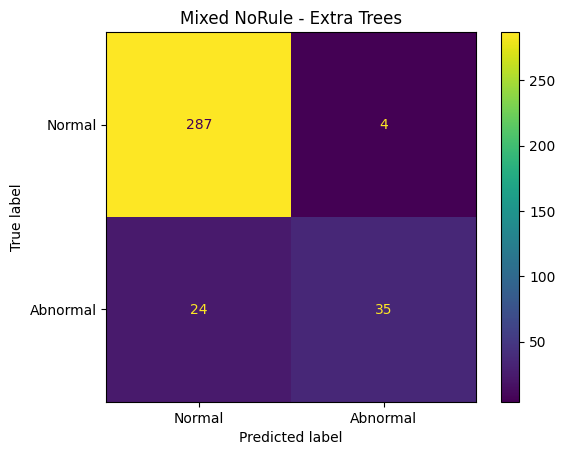

Mixed NoRule - XGBoost
Accuracy          : 0.9286
Balanced Accuracy : 0.8152
Precision         : 0.9048
Recall            : 0.6441
F1-score          : 0.7525

              precision    recall  f1-score   support

      Normal       0.93      0.99      0.96       291
    Abnormal       0.90      0.64      0.75        59

    accuracy                           0.93       350
   macro avg       0.92      0.82      0.86       350
weighted avg       0.93      0.93      0.92       350



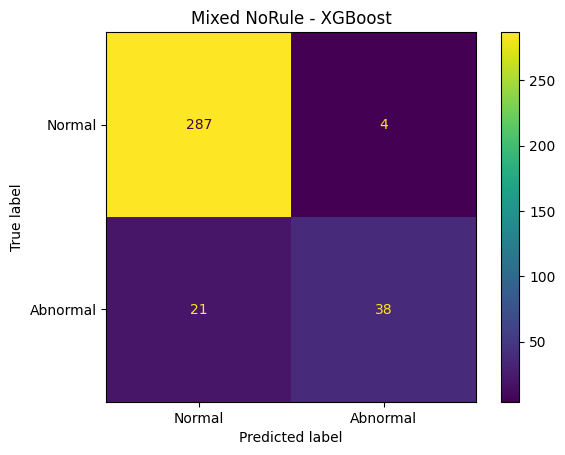

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Mixed NoRule - XGBoost,0.928571,0.815161,0.904762,0.644068,0.752475
1,Mixed NoRule - Decision Tree,0.911429,0.845390,0.733333,0.745763,0.739496
2,Mixed NoRule - Random Forest,0.920000,0.796494,0.878049,0.610169,0.720000
3,Mixed NoRule - Extra Trees,0.920000,0.789737,0.897436,0.593220,0.714286
4,Mixed NoRule - Logistic Regression,0.882857,0.787670,0.655172,0.644068,0.649573


In [57]:
# =========================================================
# Mixed label without rule-related features - 5 models
# =========================================================

mixed_no_rule_results = []

# Logistic Regression
lr_mixed_nr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

lr_mixed_nr.fit(X_train_m_no_rule, y_train_m)
mixed_no_rule_results.append(
    evaluate_classifier(lr_mixed_nr, X_test_m_no_rule, y_test_m, "Mixed NoRule - Logistic Regression")
)


# Decision Tree
dt_mixed_nr = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

dt_mixed_nr.fit(X_train_m_no_rule, y_train_m)
mixed_no_rule_results.append(
    evaluate_classifier(dt_mixed_nr, X_test_m_no_rule, y_test_m, "Mixed NoRule - Decision Tree")
)


# Random Forest
rf_mixed_nr = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_mixed_nr.fit(X_train_m_no_rule, y_train_m)
mixed_no_rule_results.append(
    evaluate_classifier(rf_mixed_nr, X_test_m_no_rule, y_test_m, "Mixed NoRule - Random Forest")
)


# Extra Trees
et_mixed_nr = ExtraTreesClassifier(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_mixed_nr.fit(X_train_m_no_rule, y_train_m)
mixed_no_rule_results.append(
    evaluate_classifier(et_mixed_nr, X_test_m_no_rule, y_test_m, "Mixed NoRule - Extra Trees")
)


# XGBoost
neg = np.sum(y_train_m == 0)
pos = np.sum(y_train_m == 1)
scale_pos_weight = neg / pos if pos > 0 else 1

xgb_mixed_nr = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.0,
    reg_lambda=1.0,
    reg_alpha=0.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_mixed_nr.fit(X_train_m_no_rule, y_train_m)
mixed_no_rule_results.append(
    evaluate_classifier(xgb_mixed_nr, X_test_m_no_rule, y_test_m, "Mixed NoRule - XGBoost")
)


mixed_no_rule_results_df = pd.DataFrame(mixed_no_rule_results).sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

display(mixed_no_rule_results_df)

In [58]:
# =========================================================
# Mixed label group-level aggregation
# =========================================================

session_feature_mixed_df = pd.DataFrame(stats_X_mixed, columns=feature_names_mixed)

for col in session_meta_mixed_df.columns:
    session_feature_mixed_df[col] = session_meta_mixed_df[col].values

session_feature_mixed_df["label"] = y_mixed

group_col = "group_id"

agg_funcs = ["mean", "std", "min", "max", "median"]

X_mixed_agg_df = session_feature_mixed_df.groupby(group_col)[feature_names_mixed].agg(agg_funcs)

X_mixed_agg_df.columns = [
    f"{feature}_{stat}" for feature, stat in X_mixed_agg_df.columns
]

y_mixed_agg = session_feature_mixed_df.groupby(group_col)["label"].first()

label_nunique = session_feature_mixed_df.groupby(group_col)["label"].nunique()
inconsistent_groups = label_nunique[label_nunique > 1]

print("Mixed aggregated X shape:", X_mixed_agg_df.shape)
print("Mixed aggregated y distribution:")
print(y_mixed_agg.value_counts())
print("Label 不一致 group 數量:", len(inconsistent_groups))

X_mixed_agg_df = X_mixed_agg_df.replace([np.inf, -np.inf], np.nan)
X_mixed_agg_df = X_mixed_agg_df.fillna(X_mixed_agg_df.median(numeric_only=True))
X_mixed_agg_df = X_mixed_agg_df.fillna(0)

X_mixed_agg = X_mixed_agg_df.values
y_mixed_agg_np = y_mixed_agg.values

print("X_mixed_agg:", X_mixed_agg.shape)
print("y_mixed_agg:", y_mixed_agg_np.shape)

Mixed aggregated X shape: (63, 1640)
Mixed aggregated y distribution:
label
0    40
1    23
Name: count, dtype: int64
Label 不一致 group 數量: 0
X_mixed_agg: (63, 1640)
y_mixed_agg: (63,)


In [59]:
# =========================================================
# Mixed Aggregated 5-Fold CV
# =========================================================

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0)
}

neg = np.sum(y_mixed_agg_np == 0)
pos = np.sum(y_mixed_agg_np == 1)
scale_pos_weight_mixed_agg = neg / pos if pos > 0 else 1

mixed_agg_models = {
    "Mixed Agg - Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=1.0,
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]),

    "Mixed Agg - Decision Tree": DecisionTreeClassifier(
        criterion="gini",
        max_depth=3,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42
    ),

    "Mixed Agg - Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Mixed Agg - Extra Trees": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Mixed Agg - XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.0,
        reg_lambda=1.0,
        reg_alpha=0.0,
        scale_pos_weight=scale_pos_weight_mixed_agg,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

mixed_agg_cv_rows = []

for model_name, model in mixed_agg_models.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    scores = cross_validate(
        model,
        X_mixed_agg,
        y_mixed_agg_np,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),
        "Balanced Accuracy Mean": scores["test_balanced_accuracy"].mean(),
        "Balanced Accuracy Std": scores["test_balanced_accuracy"].std(),
        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),
        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),
        "F1-score Mean": scores["test_f1"].mean(),
        "F1-score Std": scores["test_f1"].std()
    }

    mixed_agg_cv_rows.append(row)

    print(f"Accuracy          : {row['Accuracy Mean']:.4f} +/- {row['Accuracy Std']:.4f}")
    print(f"Balanced Accuracy : {row['Balanced Accuracy Mean']:.4f} +/- {row['Balanced Accuracy Std']:.4f}")
    print(f"Precision         : {row['Precision Mean']:.4f} +/- {row['Precision Std']:.4f}")
    print(f"Recall            : {row['Recall Mean']:.4f} +/- {row['Recall Std']:.4f}")
    print(f"F1-score          : {row['F1-score Mean']:.4f} +/- {row['F1-score Std']:.4f}")

mixed_agg_cv_df = pd.DataFrame(mixed_agg_cv_rows).sort_values(
    by="F1-score Mean",
    ascending=False
).reset_index(drop=True)

display(mixed_agg_cv_df)

Mixed Agg - Logistic Regression
Accuracy          : 0.9385 +/- 0.0897
Balanced Accuracy : 0.9275 +/- 0.1026
Precision         : 0.9500 +/- 0.1000
Recall            : 0.8800 +/- 0.1600
F1-score          : 0.9111 +/- 0.1296
Mixed Agg - Decision Tree
Accuracy          : 0.9846 +/- 0.0308
Balanced Accuracy : 0.9800 +/- 0.0400
Precision         : 1.0000 +/- 0.0000
Recall            : 0.9600 +/- 0.0800
F1-score          : 0.9778 +/- 0.0444
Mixed Agg - Random Forest
Accuracy          : 0.9846 +/- 0.0308
Balanced Accuracy : 0.9800 +/- 0.0400
Precision         : 1.0000 +/- 0.0000
Recall            : 0.9600 +/- 0.0800
F1-score          : 0.9778 +/- 0.0444
Mixed Agg - Extra Trees
Accuracy          : 1.0000 +/- 0.0000
Balanced Accuracy : 1.0000 +/- 0.0000
Precision         : 1.0000 +/- 0.0000
Recall            : 1.0000 +/- 0.0000
F1-score          : 1.0000 +/- 0.0000
Mixed Agg - XGBoost
Accuracy          : 0.9679 +/- 0.0393
Balanced Accuracy : 0.9750 +/- 0.0306
Precision         : 0.9267 +/- 0.090

,Model,Accuracy Mean,Accuracy Std,Balanced Accuracy Mean,Balanced Accuracy Std,Precision Mean,Precision Std,Recall Mean,Recall Std,F1-score Mean,F1-score Std
0,Mixed Agg - Extra Trees,1.000000,0.000000,1.0000,0.000000,1.000000,0.000000,1.00,0.00,1.000000,0.000000
1,Mixed Agg - Random Forest,0.984615,0.030769,0.9800,0.040000,1.000000,0.000000,0.96,0.08,0.977778,0.044444
2,Mixed Agg - Decision Tree,0.984615,0.030769,0.9800,0.040000,1.000000,0.000000,0.96,0.08,0.977778,0.044444
3,Mixed Agg - XGBoost,0.967949,0.039307,0.9750,0.030619,0.926667,0.090431,1.00,0.00,0.959596,0.049895
4,Mixed Agg - Logistic Regression,0.938462,0.089707,0.9275,0.102591,0.950000,0.100000,0.88,0.16,0.911111,0.129577
